# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [4]:
# Import warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [5]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [20]:
# Try loading one file
# Update this path to include the 'MyDrive' prefix
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Colab_Notebooks/NYC_TAXI_ASSIGNMENT/Datasets_and_Dictionary/trip_records/'
df = pd.read_parquet(f'{data_path}/2023-1.parquet')
print("January 2023 data info:")
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
January 2023 data info:
<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  imp

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [28]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
data_path = '/content/drive/MyDrive/Colab_Notebooks/NYC_TAXI_ASSIGNMENT/Datasets_and_Dictionary/trip_records/'
if not os.path.exists(data_path):
    print(f"Directory {data_path} does not exist. Please check the path.")
    print(f"Current working directory: {os.getcwd()}")
else:
    os.chdir(data_path)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        print(f"Processing: {file_name}")
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)
        # Extract date and hour from pickup datetime
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_df['pickup_date'].unique():
            date_df = month_df[month_df['pickup_date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_df = date_df[date_df['pickup_hour'] == hour]
                if len(hour_df) > 0:

                 # Sample 5% of the hourly data randomly
                 hour_sample = hour_df.sample(frac=0.05, random_state=42)

                 # add data of this hour to the dataframe
                 sampled_data = pd.concat([sampled_data, hour_sample], axis=0)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], axis=0)
        print(f"  Sampled {len(sampled_data)} rows from {file_name}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
print("\nFINAL RESULT:")
print(f"Total sampled rows: {len(df)}")
print(f"Shape: {df.shape}")

Processing: 2023-1.parquet
  Sampled 152087 rows from 2023-1.parquet
Processing: 2023-2.parquet
  Sampled 168696 rows from 2023-2.parquet
Processing: 2023-3.parquet
  Sampled 163786 rows from 2023-3.parquet
Processing: 2023-4.parquet
  Sampled 139641 rows from 2023-4.parquet
Processing: 2023-5.parquet
  Sampled 144458 rows from 2023-5.parquet
Processing: 2023-6.parquet
  Sampled 162910 rows from 2023-6.parquet
Processing: 2023-7.parquet
  Sampled 174068 rows from 2023-7.parquet
Processing: 2023-8.parquet
  Sampled 143782 rows from 2023-8.parquet
Processing: 2023-9.parquet
  Sampled 140875 rows from 2023-9.parquet
Processing: 2023-10.parquet
  Sampled 174255 rows from 2023-10.parquet
Processing: 2023-11.parquet
  Sampled 165133 rows from 2023-11.parquet
Processing: 2023-12.parquet
  Sampled 166709 rows from 2023-12.parquet

FINAL RESULT:
Total sampled rows: 1896400
Shape: (1896400, 22)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [29]:
# Store the df in csv/parquet
max_entries = 300000
print("First sampled data shape =",df.shape)

if len(df) > max_entries:
    df = df.sample(n=max_entries, random_state=42)
df.to_csv('/content/drive/MyDrive/Colab_Notebooks/NYC_TAXI_ASSIGNMENT/Datasets_and_Dictionary/trip_records/nyc_taxi_2023_combined.csv', index=False)

print("Final shape =", df.shape)

First sampled data shape = (1896400, 22)
Final shape = (300000, 22)


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [30]:
# Load the new data file

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/NYC_TAXI_ASSIGNMENT/Datasets_and_Dictionary/trip_records/nyc_taxi_2023_combined.csv")

In [31]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,1,2023-10-02 18:26:58,2023-10-02 18:40:44,1.0,2.20,1.0,N,162,236,1,...,0.5,3.95,0.0,1.0,23.85,2.5,NaN,2023-10-02,18,0.0
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,2,...,0.5,0.00,0.0,1.0,14.00,2.5,0.0,2023-01-10,14,NaN
2,2,2023-07-11 20:10:33,2023-07-11 20:20:35,1.0,1.34,1.0,N,43,239,2,...,0.5,0.00,0.0,1.0,15.70,2.5,NaN,2023-07-11,20,0.0
3,1,2023-04-12 08:29:38,2023-04-12 08:36:14,1.0,0.80,1.0,N,88,261,1,...,0.5,8.00,0.0,1.0,20.60,2.5,NaN,2023-04-12,8,0.0
4,1,2023-12-08 15:30:29,2023-12-08 15:50:44,1.0,5.70,1.0,Y,166,243,1,...,0.5,7.05,0.0,1.0,35.35,0.0,NaN,2023-12-08,15,0.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               300000 non-null  int64  
 1   tpep_pickup_datetime   300000 non-null  object 
 2   tpep_dropoff_datetime  300000 non-null  object 
 3   passenger_count        289715 non-null  float64
 4   trip_distance          300000 non-null  float64
 5   RatecodeID             289715 non-null  float64
 6   store_and_fwd_flag     289715 non-null  object 
 7   PULocationID           300000 non-null  int64  
 8   DOLocationID           300000 non-null  int64  
 9   payment_type           300000 non-null  int64  
 10  fare_amount            300000 non-null  float64
 11  extra                  300000 non-null  float64
 12  mta_tax                300000 non-null  float64
 13  tip_amount             300000 non-null  float64
 14  tolls_amount           300000 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [39]:
# Fix the index and drop any columns that are not needed
df = df.reset_index(drop=True)
print(df.head())


   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2023-10-02 18:26:58   2023-10-02 18:40:44              1.0   
1         2  2023-01-10 14:11:52   2023-01-10 14:21:05              1.0   
2         2  2023-07-11 20:10:33   2023-07-11 20:20:35              1.0   
3         1  2023-04-12 08:29:38   2023-04-12 08:36:14              1.0   
4         1  2023-12-08 15:30:29   2023-12-08 15:50:44              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           2.20         1.0                  N           162           236   
1           0.90         1.0                  N           186           170   
2           1.34         1.0                  N            43           239   
3           0.80         1.0                  N            88           261   
4           5.70         1.0                  Y           166           243   

   payment_type  ...  mta_tax  tip_amount  tolls_amount  \
0             1

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [40]:
# Combine the two airport fee columns
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

# Drop the column 'Airport_fee'
df = df.drop(columns=['Airport_fee'])
print(df.head())


   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2023-10-02 18:26:58   2023-10-02 18:40:44              1.0   
1         2  2023-01-10 14:11:52   2023-01-10 14:21:05              1.0   
2         2  2023-07-11 20:10:33   2023-07-11 20:20:35              1.0   
3         1  2023-04-12 08:29:38   2023-04-12 08:36:14              1.0   
4         1  2023-12-08 15:30:29   2023-12-08 15:50:44              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           2.20         1.0                  N           162           236   
1           0.90         1.0                  N           186           170   
2           1.34         1.0                  N            43           239   
3           0.80         1.0                  N            88           261   
4           5.70         1.0                  Y           166           243   

   payment_type  ...  extra  mta_tax  tip_amount  tolls_amount  \
0       

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [43]:
# check where values of fare amount are negative

cols = ["fare_amount" , "extra" , "mta_tax" , "improvement_surcharge" , "total_amount" , "congestion_surcharge" ]

negative_values = pd.DataFrame(
    {
        "negative_vlaues" : (df[cols] < 0).sum(),
    })

print(negative_values)


                       negative_vlaues
fare_amount                          0
extra                                0
mta_tax                             13
improvement_surcharge               13
total_amount                        13
congestion_surcharge                 8


Did you notice something different in the `RatecodeID` column for above records?

In [44]:
# Analyse RatecodeID for the negative fare amounts
negative_rows = df[df['total_amount'] < 0]

print("Rows with negative total_amount:", len(negative_rows))
print()

# Check row items
negative_rows[['RatecodeID', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
               'tolls_amount', 'improvement_surcharge', 'total_amount']]


# We have negative values in ratecode_id 1 or 2.


Rows with negative total_amount: 13



,RatecodeID,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
7420,2.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.75
126775,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50
132267,2.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00
161290,2.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00
175409,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00
185175,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25
207907,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00
228690,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00
249352,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50
260242,1.0,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25


In [47]:
# Find which columns have negative values
all_columns = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                 'improvement_surcharge', 'total_amount', 'congestion_surcharge']

print("Columns with negative values:")

for col in all_columns:
    negative_count = len(df[df[col] < 0])
    if negative_count > 0:
        print(f"Column name:{col}: {negative_count} negative values")


Columns with negative values:
Column name:mta_tax: 13 negative values
Column name:improvement_surcharge: 13 negative values
Column name:total_amount: 13 negative values
Column name:congestion_surcharge: 8 negative values


In [48]:
# fix these negative values
print("Total rows:", len(df))

# Drop rows where total_amount is negative

before = len(df)
df = df[df['total_amount'] >= 0]
print("Rows removed:", before - len(df))
print("After removing negative values:", len(df))
print("Preview of dataset after removing rows with negative values:")
print(df.head())


Total rows: 300000
Rows removed: 13
After removing negative values: 299987
Preview of dataset after removing rows with negative values:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2023-10-02 18:26:58   2023-10-02 18:40:44              1.0   
1         2  2023-01-10 14:11:52   2023-01-10 14:21:05              1.0   
2         2  2023-07-11 20:10:33   2023-07-11 20:20:35              1.0   
3         1  2023-04-12 08:29:38   2023-04-12 08:36:14              1.0   
4         1  2023-12-08 15:30:29   2023-12-08 15:50:44              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           2.20         1.0                  N           162           236   
1           0.90         1.0                  N           186           170   
2           1.34         1.0                  N            43           239   
3           0.80         1.0                  N            88           261   
4           5.70  

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [49]:
# Find the proportion of missing values in each column
missing = df.isnull().sum()
total = len(df)

print("Missing values and proportion:")
print()

for col in df.columns:
    if missing[col] > 0:
        proportion = missing[col] / total * 100
        print(f"{col}: {missing[col]} missing proportion:{proportion:.2f}%")


Missing values and proportion:

passenger_count: 10285 missing proportion:3.43%
RatecodeID: 10285 missing proportion:3.43%
store_and_fwd_flag: 10285 missing proportion:3.43%
congestion_surcharge: 10285 missing proportion:3.43%
airport_fee: 10285 missing proportion:3.43%


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [50]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
rows_with_nulls = df[df['passenger_count'].isna()]
print("Rows where 'passenger_count' is missing:")
print(rows_with_nulls)
print("Number of missing values in 'passenger_count':",
      df['passenger_count'].isna().sum())

passenger_count_mode = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(passenger_count_mode)

print("Number of missing values in 'passenger_count' after imputation:",
      df['passenger_count'].isna().sum())


Rows where 'passenger_count' is missing:
        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
23             1  2023-11-28 15:25:23   2023-11-28 15:34:12              NaN   
35             1  2023-02-15 19:32:47   2023-02-15 19:45:46              NaN   
71             1  2023-10-31 17:28:35   2023-10-31 17:38:26              NaN   
74             6  2023-07-11 14:07:55   2023-07-11 21:07:31              NaN   
89             2  2023-01-01 03:28:00   2023-01-01 03:38:00              NaN   
...          ...                  ...                   ...              ...   
299695         1  2023-07-27 18:04:23   2023-07-27 18:22:57              NaN   
299713         2  2023-05-07 07:36:42   2023-05-07 08:05:53              NaN   
299717         1  2023-11-21 13:08:54   2023-11-21 13:32:17              NaN   
299867         1  2023-10-20 23:33:48   2023-10-20 23:55:53              NaN   
299914         1  2023-01-30 13:53:59   2023-01-30 14:07:52              NaN   

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [53]:
# Fix missing values in 'RatecodeID'
non_null = df["RatecodeID"].isna().sum()
print(non_null)
ratecode_mode = df['RatecodeID'].mode()[0]
print("Most frequent value (mode) of 'RatecodeID':", ratecode_mode)
df['RatecodeID'].fillna(ratecode_mode, inplace=True)

print("Number of missing values in 'RatecodeID' after imputation:",
      df['RatecodeID'].isna().sum())


10285
Most frequent value (mode) of 'RatecodeID': 1.0
Number of missing values in 'RatecodeID' after imputation: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [56]:
# handle null values in congestion_surcharge
totalNullValuesCongestionSurcharge = df['congestion_surcharge'].isna().sum()

congestion_surcharge_mode = df['congestion_surcharge'].mode()[0]
print("Most frequent value (mode) of 'congestion_surcharge':", congestion_surcharge_mode)

# Replace null values with the most frequent value
df.loc[:, 'congestion_surcharge'] = df['congestion_surcharge'].fillna(congestion_surcharge_mode)

print("Missing values in 'congestion_surcharge' after imputation:",
      df['congestion_surcharge'].isna().sum())



Most frequent value (mode) of 'congestion_surcharge': 2.5
Missing values in 'congestion_surcharge' after imputation: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [57]:
# Handle any remaining missing values
missing_value_ratio = df.isna().mean() * 100
print(f"Missing values proportion before applying Fix :\n {missing_value_ratio}")

for col in df.columns:
    missing_before = df[col].isna().sum()
    dataType = df[col].dtype

    if missing_before > 0:
      df[col] = df[col].fillna(df[col].mode()[0])

    missing_after = df[col].isna().sum()

print(f"\n After applying Fix :\n {df.isna().sum()}")



Missing values proportion before applying Fix :
 VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          0.000000
trip_distance            0.000000
RatecodeID               0.000000
store_and_fwd_flag       3.428482
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     0.000000
airport_fee              3.428482
pickup_date              0.000000
pickup_hour              0.000000
dtype: float64

 After applying Fix :
 VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocatio

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [59]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
print("Shape:", df.shape)
df.describe()

Shape: (299987, 21)


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000,299987.000000
mean,1.733862,1.356922,3.714308,1.611320,165.406444,164.095614,1.162920,19.874841,1.587470,0.495331,3.553115,0.600793,0.999067,28.949833,2.315559,0.138008,14.257338
std,0.447932,0.880277,74.915972,7.253059,64.046885,69.704396,0.506751,18.603632,1.831669,0.048673,4.080303,2.197431,0.027839,23.117970,0.653518,0.457673,5.803650
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.040000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.100000,2.500000,0.000000,15.000000
75%,2.000000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.800000,2.500000,0.000000,19.000000
max,6.000000,8.000000,30430.040000,99.000000,265.000000,265.000000,4.000000,1375.000000,14.250000,4.000000,200.000000,95.000000,1.000000,1435.190000,2.500000,1.750000,23.000000


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [64]:
# remove passenger_count > 6
print("Print passenger count before cleaning:", df["passenger_count"].value_counts())
# Only consider passenger_count <=6
df = df[df['passenger_count'] <= 6]

print("Print passenger count before cleaning:", df["passenger_count"].value_counts())

Print passenger count before cleaning: passenger_count
1.0    228259
2.0     43734
3.0     10949
4.0      6131
0.0      4627
5.0      3765
6.0      2519
7.0         2
8.0         1
Name: count, dtype: int64
Print passenger count before cleaning: passenger_count
1.0    228259
2.0     43734
3.0     10949
4.0      6131
0.0      4627
5.0      3765
6.0      2519
Name: count, dtype: int64


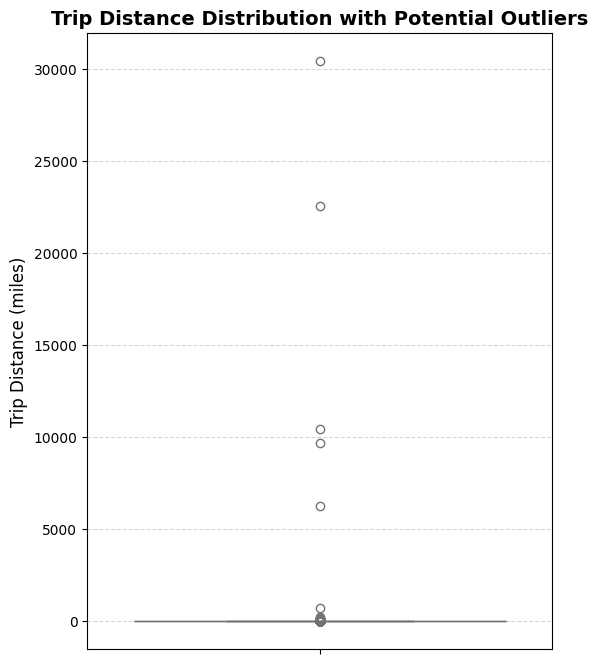

Trip distance statistics:

count    299984.000000
mean          3.714319
std          74.916346
min           0.000000
25%           1.040000
50%           1.790000
75%           3.400000
max       30430.040000
Name: trip_distance, dtype: float64


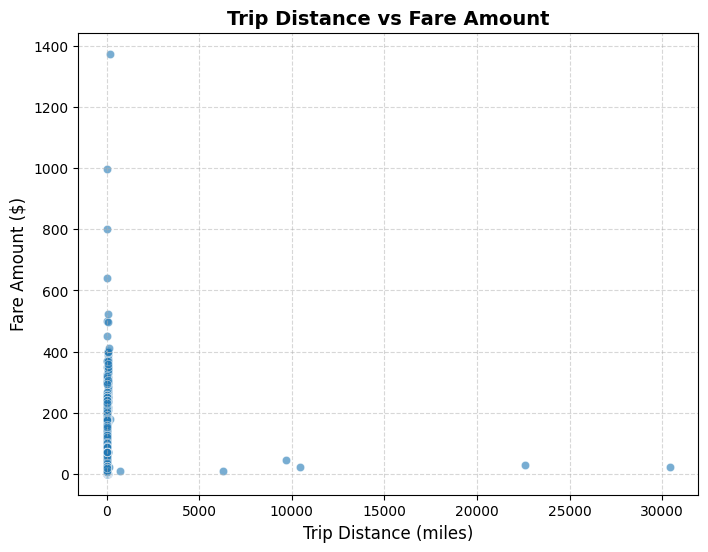

In [66]:
# Continue with outlier handling
# Check for potential outliers in 'trip_distance' using a boxplot

plt.figure(figsize=(6,8))
sns.boxplot(y=df["trip_distance"], color='lightgreen')
plt.title("Trip Distance Distribution with Potential Outliers", fontsize=14, fontweight='bold')
plt.ylabel("Trip Distance (miles)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Trip distance statistics:\n")
print(df['trip_distance'].describe())

# Relationship between 'trip_distance' and 'fare_amount'

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["trip_distance"], y=df["fare_amount"], alpha=0.6)
plt.title("Trip Distance vs Fare Amount", fontsize=14, fontweight='bold')
plt.xlabel("Trip Distance (miles)", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


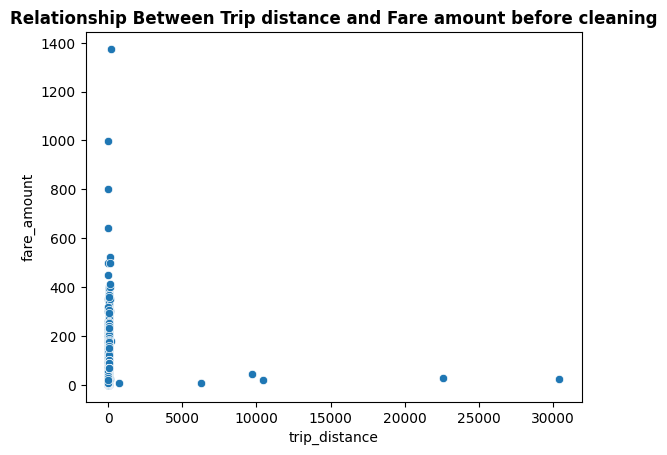

Step 1: Count of records identified as outliers: (8, 21)
Step 1: Count of records after outlier removal: (299976, 21)
Step 2: Count of records identified as outliers: (7, 21)
Step 2: Count of records after outlier removal: (299969, 21)
Step 3: Count of records identified as outliers: (6, 21)
Step 3: Count of records after outlier removal: (299963, 21)
Step 4: Count of records identified as outliers: (10282, 21)
Step 4: Count of records after outlier removal: (289681, 21)
Step 5: Count of records with invalid RatecodeID: (1649, 21)
Step 5: Count of records after removing invalid RatecodeID: (288032, 21)


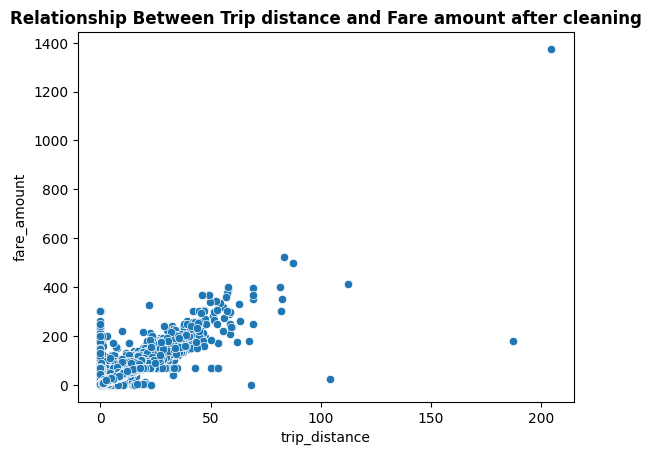

In [67]:
# Continue with outlier handling

# Relationship Between Trip distance and Fare amount before cleaning
sns.scatterplot(x=df["trip_distance"], y= df["fare_amount"])
plt.title('Relationship Between Trip distance and Fare amount before cleaning', fontsize=12, fontweight='bold')
plt.show()

# Step 1: Remove entries where trip_distance is less than 5 and fare_amount is unusually high (>300)
outliers_trip_fare = df[(df['trip_distance'] < 5) & (df['fare_amount'] > 300)]
print("Step 1: Count of records identified as outliers:", outliers_trip_fare.shape)
cleaned_step1 = df[~((df['trip_distance'] < 5) & (df['fare_amount'] > 300))]
print("Step 1: Count of records after outlier removal:", cleaned_step1.shape)

# Step 2: Remove entries where trip_distance and fare_amount are 0 but pickup and dropoff zones differ
outliers_zero_trip = cleaned_step1[
    (cleaned_step1['trip_distance'] == 0) &
    (cleaned_step1['fare_amount'] == 0) &
    (cleaned_step1['PULocationID'] != cleaned_step1['DOLocationID'])
]
print("Step 2: Count of records identified as outliers:", outliers_zero_trip.shape)
cleaned_step2 = cleaned_step1[~(
    (cleaned_step1['trip_distance'] == 0) &
    (cleaned_step1['fare_amount'] == 0) &
    (cleaned_step1['PULocationID'] != cleaned_step1['DOLocationID'])
)]
print("Step 2: Count of records after outlier removal:", cleaned_step2.shape)

# Step 3: Remove entries where trip_distance > 250 (extremely rare long trips)
outliers_long_trips = cleaned_step2[cleaned_step2['trip_distance'] > 250]
print("Step 3: Count of records identified as outliers:", outliers_long_trips.shape)
cleaned_step3 = cleaned_step2[~(cleaned_step2['trip_distance'] > 250)]
print("Step 3: Count of records after outlier removal:", cleaned_step3.shape)

# Step 4: Remove entries with invalid payment_type (e.g., 0)
outliers_invalid_payment = cleaned_step3[cleaned_step3['payment_type'] == 0]
print("Step 4: Count of records identified as outliers:", outliers_invalid_payment.shape)
cleaned_step4 = cleaned_step3[cleaned_step3['payment_type'] != 0]
print("Step 4: Count of records after outlier removal:", cleaned_step4.shape)

# Step 5: Remove entries with invalid RatecodeID (valid: 1-6)
invalid_ratecode = cleaned_step4[~cleaned_step4['RatecodeID'].isin([1,2,3,4,5,6])]
print("Step 5: Count of records with invalid RatecodeID:", invalid_ratecode.shape)
df_final = cleaned_step4[cleaned_step4['RatecodeID'].isin([1,2,3,4,5,6])]
print("Step 5: Count of records after removing invalid RatecodeID:", df_final.shape)

# Relationship Between Trip distance and Fare amount after cleaning
sns.scatterplot(x=df_final["trip_distance"], y= df_final["fare_amount"])
plt.title('Relationship Between Trip distance and Fare amount after cleaning', fontsize=12, fontweight='bold')
plt.show()

In [69]:
# Do any columns need standardising?

# check column names
print("Updated Column names:")
print(df_final.columns.tolist())
print()

# the datetime columns updated to proper datetime format
# Use .loc to avoid SettingWithCopyWarning
df_final.loc[:, 'tpep_pickup_datetime'] = pd.to_datetime(df_final['tpep_pickup_datetime'])
df_final.loc[:, 'tpep_dropoff_datetime'] = pd.to_datetime(df_final['tpep_dropoff_datetime'])

print("Datetime columns `tpep_pickup_datetime` and `tpep_dropoff_datetime` have been successfully converted to datetime objects!")
print()
print("Final shape of the DataFrame after updates:", df_final.shape)

Updated Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour']

Datetime columns `tpep_pickup_datetime` and `tpep_dropoff_datetime` have been successfully converted to datetime objects!

Final shape of the DataFrame after updates: (288032, 21)


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [71]:
df_final.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_date',
 'pickup_hour']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

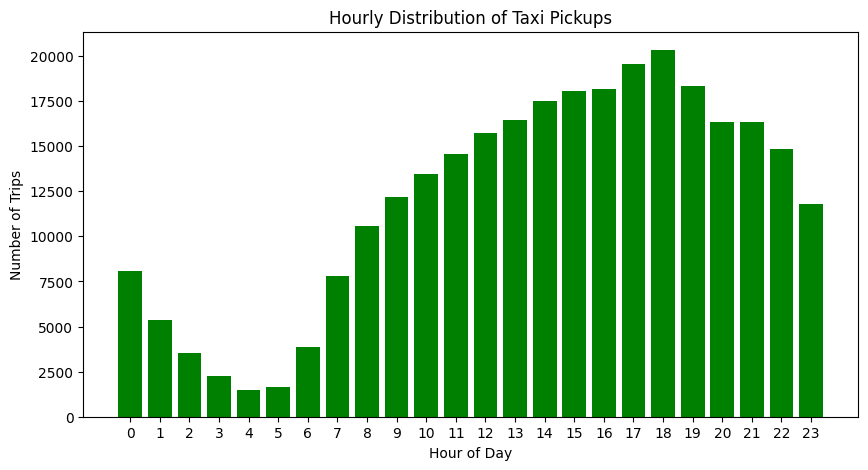

Busiest hour: 18 with 20321 trips


In [73]:
# Find and show the hourly trends in taxi pickups
hourly_trips = df_final.groupby('pickup_hour').size()

plt.figure(figsize=(10, 5))
plt.bar(hourly_trips.index, hourly_trips.values, color='green')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Distribution of Taxi Pickups')
plt.xticks(range(0, 24))
plt.show()

print("Busiest hour:", hourly_trips.idxmax(), "with", hourly_trips.max(), "trips")


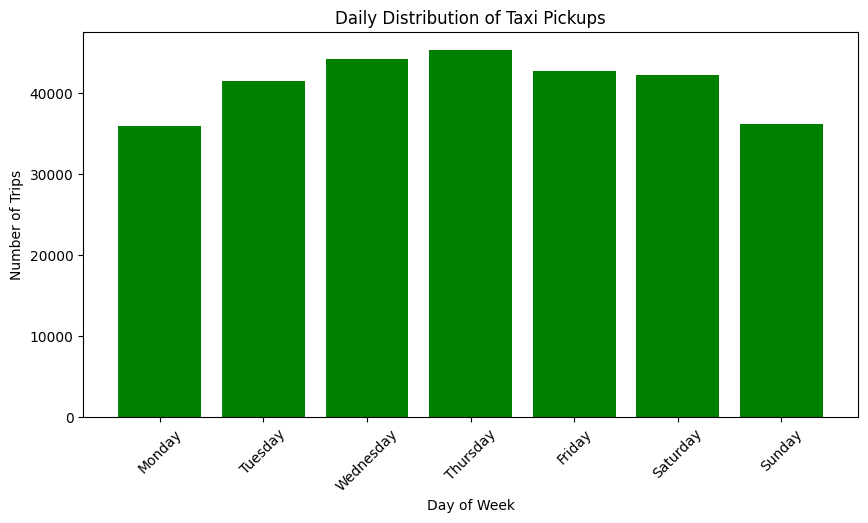

Busiest day: Thursday


In [78]:
# Find and show the daily trends in taxi pickups (days of the week)
df_final.loc[:, 'day_of_week'] = df_final['tpep_pickup_datetime'].dt.day_name()

# order days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trips = df_final.groupby('day_of_week').size().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(daily_trips.index, daily_trips.values, color='green')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Daily Distribution of Taxi Pickups')
plt.xticks(rotation=45)
plt.show()

print("Busiest day:", daily_trips.idxmax())

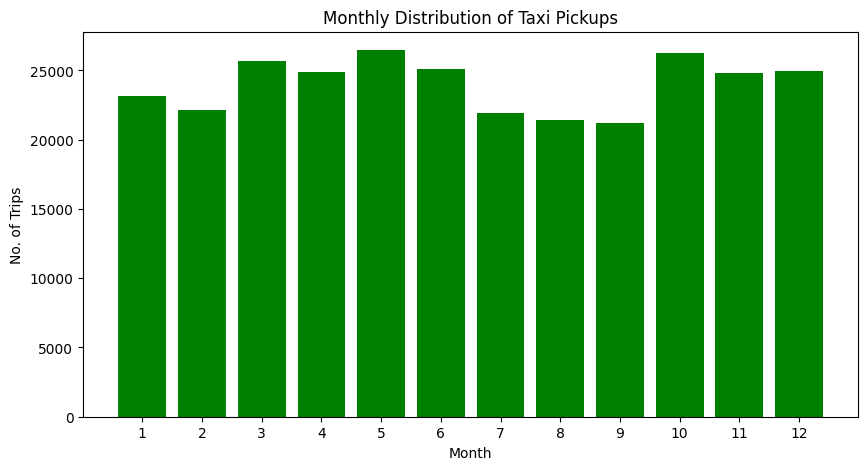

Busiest month: 5


In [79]:
# Show the monthly trends in pickups
df_final.loc[:, 'month'] = df_final['tpep_pickup_datetime'].dt.month

monthly_trips = df_final.groupby('month').size()

plt.figure(figsize=(10, 5))
plt.bar(monthly_trips.index, monthly_trips.values, color='green')
plt.xlabel('Month')
plt.ylabel('No. of Trips')
plt.title('Monthly Distribution of Taxi Pickups')
plt.xticks(range(1, 13))
plt.show()

print("Busiest month:", monthly_trips.idxmax())

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [80]:
# Analyse the above parameters

# Check for zero/negative values

cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

zero_counts = (df_final[cols_to_check] == 0).sum()
negative_counts = (df_final[cols_to_check] < 0).sum()

analysis = pd.DataFrame({
    "Zero Values": zero_counts,
    "Negative Values": negative_counts
})

print("Analysis of zero and negative values in financial and trip distance columns:\n")
print(analysis)

Analysis of zero and negative values in financial and trip distance columns:

               Zero Values  Negative Values
fare_amount             72                0
tip_amount           63096                0
total_amount            32                0
trip_distance         3383                0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [82]:
# Create a df with non zero entries for the selected parameters.
df_nonzero  = df_final.copy()

cols_to_filter = ['fare_amount', 'tip_amount', 'total_amount']

for col in cols_to_filter:
    df_nonzero = df_nonzero[df_nonzero[col] != 0]

df_nonzero = df_nonzero[~(
    (df_nonzero['trip_distance'] == 0) &
    (df_nonzero['PULocationID'] != df_nonzero['DOLocationID'])
)]

print("Original rows:", len(df_final))
print("After removing zeros:", len(df_nonzero))


Original rows: 288032
After removing zeros: 224449


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

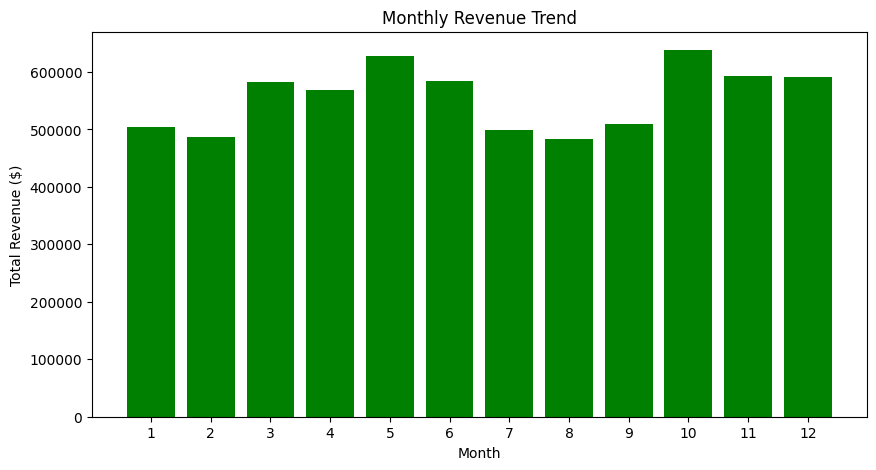

Total Revenue by Month:
month
1     503985.62
2     486130.53
3     582203.03
4     568583.74
5     627933.49
6     584265.91
7     498242.44
8     483043.09
9     509431.30
10    638256.77
11    592400.64
12    590992.08
Name: total_amount, dtype: float64


In [83]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_nonzero.groupby('month')['total_amount'].sum()

plt.figure(figsize=(10, 5))
plt.bar(monthly_revenue.index, monthly_revenue.values, color='green')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.title('Monthly Revenue Trend')
plt.xticks(range(1, 13))
plt.show()

print("Total Revenue by Month:")
print(monthly_revenue)



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue Proportion:
         Total Revenue  Percentage
quarter                           
1           1572319.18   23.589027
2           1780783.14   26.716548
3           1490716.83   22.364771
4           1821649.49   27.329654


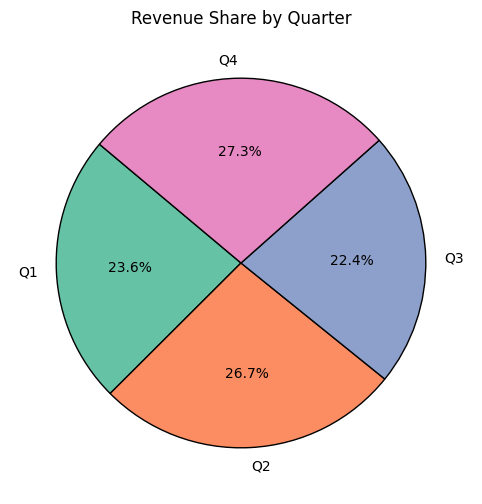

In [89]:
# Calculate proportion of each quarter

df_nonzero['quarter'] = df_nonzero['tpep_pickup_datetime'].dt.quarter

quarterly_revenue = df_nonzero.groupby('quarter')['total_amount'].sum()
total_revenue = quarterly_revenue.sum()

# calculate percentage
quarter_percent = (quarterly_revenue / total_revenue) * 100

# Combine into a DataFrame for better "in line" display
quarterly_summary = pd.DataFrame({
    'Total Revenue': quarterly_revenue,
    'Percentage': quarter_percent
})

# Calculate proportion of total revenue for each quarter
print("Quarterly Revenue Proportion:")
print(quarterly_summary)

# Plotting the quarterly revenue proportions
plt.figure(figsize=(8, 6))
plt.pie(
    quarter_percent,
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3'],
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Revenue Share by Quarter')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

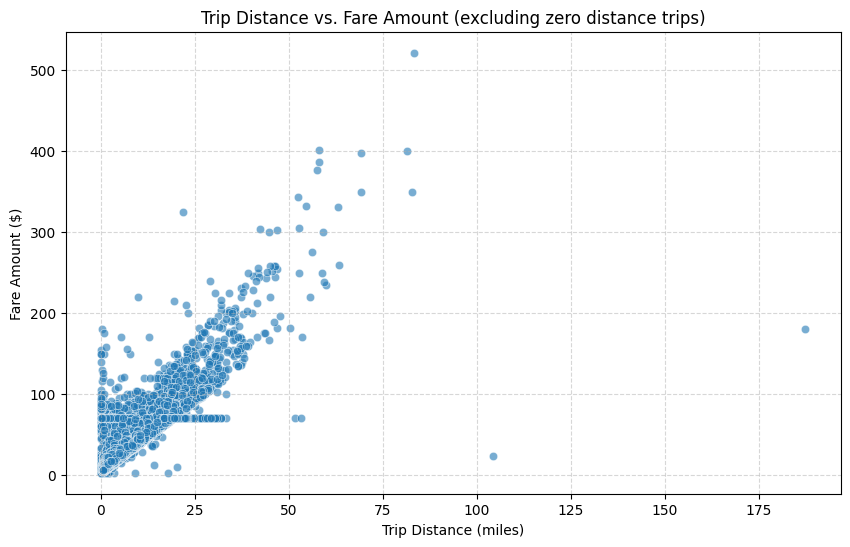

Correlation between trip_distance and fare_amount: 0.95


In [91]:
# Show how trip fare is affected by distance
# Filter out trips with zero distance for a meaningful correlation and plot
df_filtered_distance = df_nonzero[df_nonzero['trip_distance'] > 0].copy()

# Visualize the relationship between trip_distance and fare_amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_filtered_distance, alpha=0.6)
plt.title('Trip Distance vs. Fare Amount (excluding zero distance trips)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Calculate the correlation between trip_distance and fare_amount
correlation = df_filtered_distance['trip_distance'].corr(df_filtered_distance['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {correlation:.2f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

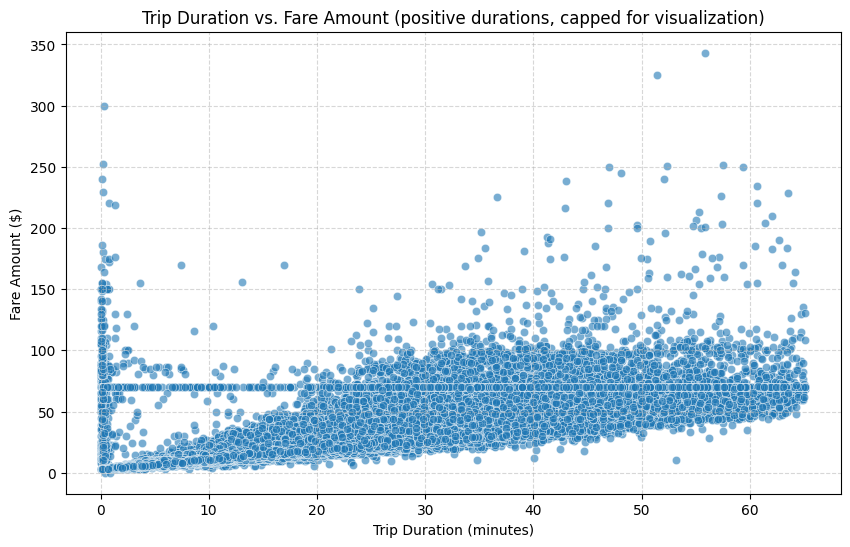

Correlation between trip_duration and fare_amount: 0.32


In [95]:
# Show relationship between fare and trip duration

# Calculate trip duration in minutes
df_nonzero.loc[:, 'trip_duration'] = (df_nonzero['tpep_dropoff_datetime'] - df_nonzero['tpep_pickup_datetime']).dt.total_seconds() / 60

# Filter out non-positive durations for more meaningful analysis and visualization
df_filtered_duration = df_nonzero[df_nonzero['trip_duration'] > 0].copy()

# For visualization, we might want to cap the duration to a reasonable extent to avoid extreme outliers distorting the plot.
# Let's cap for plotting purposes, but use the filtered range for correlation.

# Visualize the relationship between trip_duration and fare_amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_filtered_duration[df_filtered_duration['trip_duration'] < df_filtered_duration['trip_duration'].quantile(0.99)], alpha=0.6)
plt.title('Trip Duration vs. Fare Amount (positive durations, capped for visualization)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Calculate the correlation between trip_duration and fare_amount
correlation_duration_fare = df_filtered_duration['trip_duration'].corr(df_filtered_duration['fare_amount'])
print(f"Correlation between trip_duration and fare_amount: {correlation_duration_fare:.2f}")

Correlation between fare_amount and passenger_count: 0.04


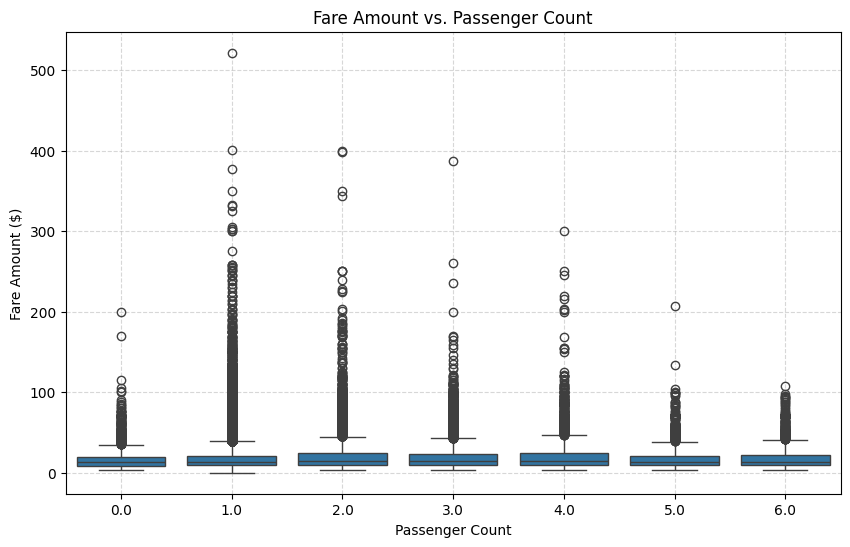

In [98]:
# Show relationship between fare and number of passengers

correlation_fare_passenger = df_nonzero['fare_amount'].corr(df_nonzero['passenger_count'])
print(f"Correlation between fare_amount and passenger_count: {correlation_fare_passenger:.2f}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_nonzero)
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Correlation between tip_amount and trip_distance: 0.77


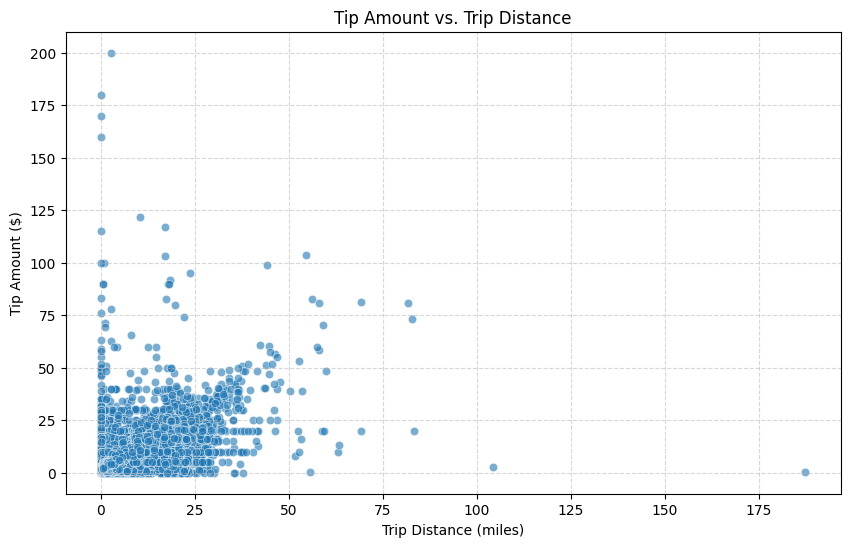

In [99]:
# Show relationship between tip and trip distance

correlation_tip_distance = df_nonzero['tip_amount'].corr(df_nonzero['trip_distance'])
print(f"Correlation between tip_amount and trip_distance: {correlation_tip_distance:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_nonzero, alpha=0.6)
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
# Analyse the distribution of different payment types (payment_type).




Distribution of Payment Types:
payment_type_name
Credit Card    224424
No Charge          12
Cash                7
Dispute             6
Name: count, dtype: int64


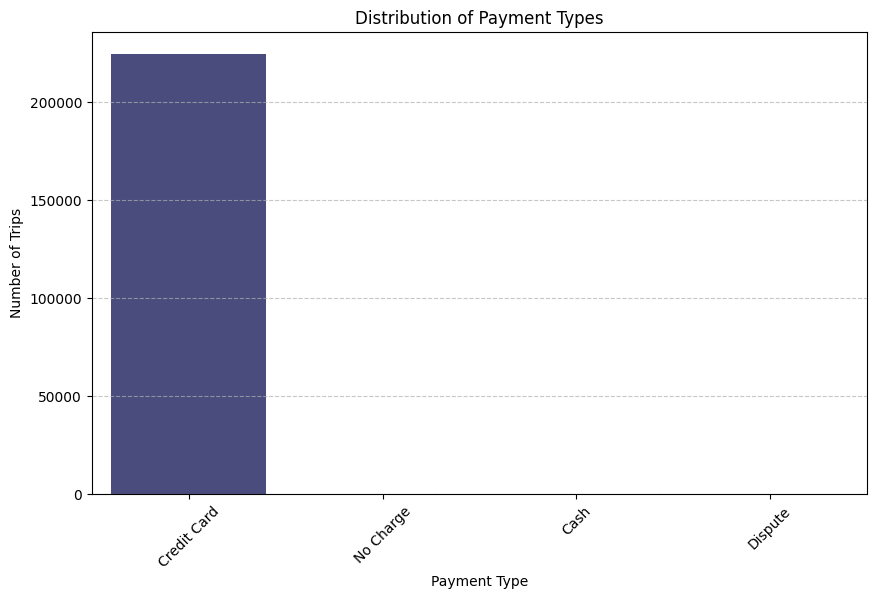

In [101]:
# Map payment_type numerical codes to descriptive names
payment_type_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute'
}

df_nonzero.loc[:, 'payment_type_name'] = df_nonzero['payment_type'].map(payment_type_map)

# Get the distribution of payment types
payment_type_counts = df_nonzero['payment_type_name'].value_counts()

print("Distribution of Payment Types:")
print(payment_type_counts)

# Visualize the distribution of payment types
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_type_counts.index, y=payment_type_counts.values, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [102]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [106]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Colab_Notebooks/NYC_TAXI_ASSIGNMENT/Datasets_and_Dictionary/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

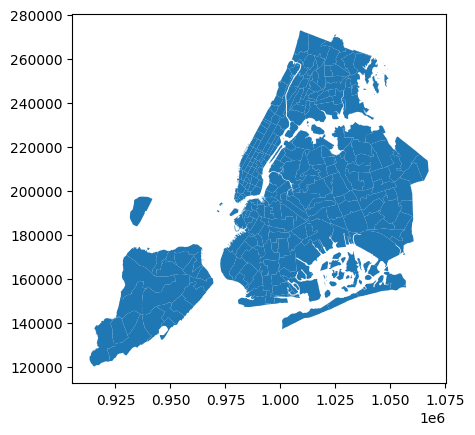

In [107]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [109]:
# Merge zones and trip records using locationID and PULocationID
df_merged = df_nonzero.merge(zones[['LocationID', 'zone', 'borough', 'geometry']], left_on='PULocationID', right_on='LocationID', how='left')
display(df_merged.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,day_of_week,month,quarter,trip_duration,payment_type_name,LocationID,zone,borough,geometry
0,1,2023-10-02 18:26:58,2023-10-02 18:40:44,1.0,2.20,1.0,N,162,236,1,...,18,Monday,10,4,13.766667,Credit Card,162.0,Midtown East,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21..."
1,1,2023-04-12 08:29:38,2023-04-12 08:36:14,1.0,0.80,1.0,N,88,261,1,...,8,Wednesday,4,2,6.600000,Credit Card,88.0,Financial District South,Manhattan,"POLYGON ((981547.706 196045.255, 981628.588 19..."
2,1,2023-12-08 15:30:29,2023-12-08 15:50:44,1.0,5.70,1.0,Y,166,243,1,...,15,Friday,12,4,20.250000,Credit Card,166.0,Morningside Heights,Manhattan,"POLYGON ((996131.213 235950.777, 996354.986 23..."
3,2,2023-01-27 08:00:44,2023-01-27 08:18:51,2.0,2.68,1.0,N,140,74,1,...,8,Friday,1,1,18.116667,Credit Card,140.0,Lenox Hill East,Manhattan,"POLYGON ((995735.062 215619.835, 995670.105 21..."
4,2,2023-04-17 10:35:47,2023-04-17 10:40:33,1.0,0.82,1.0,N,238,239,1,...,10,Monday,4,2,4.766667,Credit Card,238.0,Upper West Side North,Manhattan,"POLYGON ((992877.88 225627.534, 992741.735 225..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [110]:
# Group data by location and calculate the number of trips

trips_per_zone = df_merged['PULocationID'].value_counts().reset_index()
trips_per_zone.columns = ['LocationID', 'trip_count']
display(trips_per_zone.head())

,LocationID,trip_count
0,237,11078
1,161,10787
2,132,10189
3,236,9942
4,162,8261


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [111]:
# Merge trip counts back to the zones GeoDataFrame
zones = zones.merge(trips_per_zone, on='LocationID', how='left')
# Fill NaN values in 'trip_count' with 0 for zones with no trips
zones['trip_count'] = zones['trip_count'].fillna(0)

display(zones.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",13.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",0.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",248.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

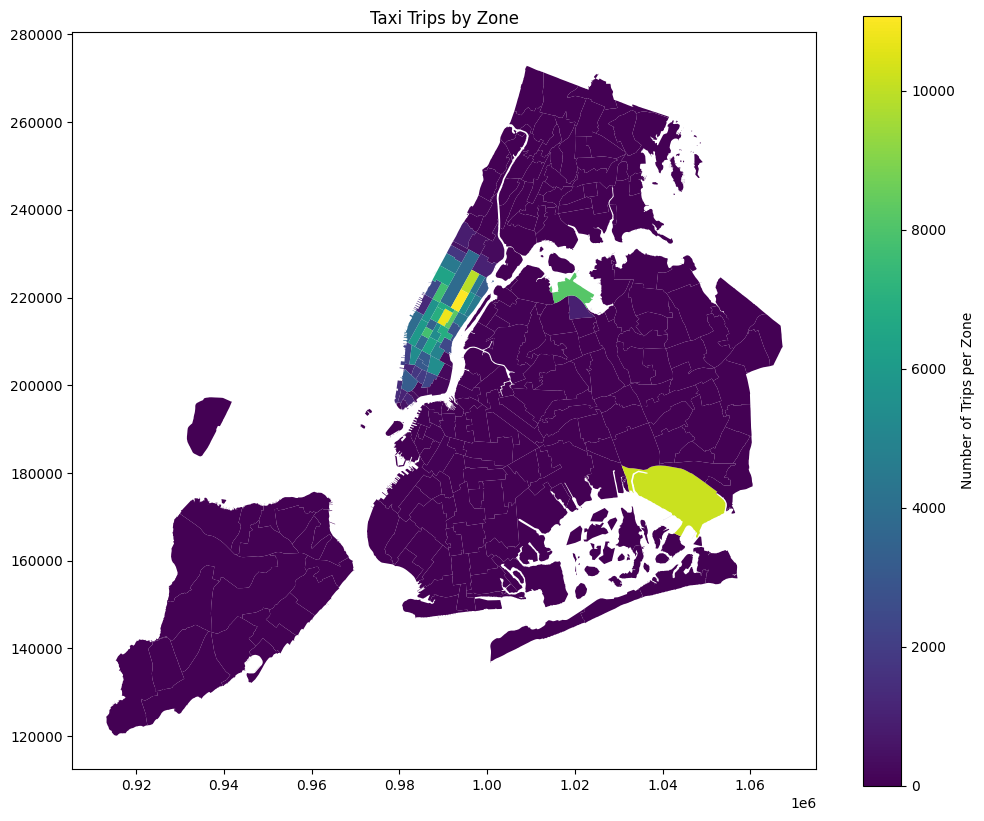

In [113]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

zones.plot(
    column = 'trip_count',
    ax = ax,
    legend = True,
    legend_kwds = {'label': "Number of Trips per Zone", 'orientation': "vertical"},
    cmap = 'viridis'
)
plt.title('Taxi Trips by Zone')
plt.show()

In [114]:
# can you try displaying the zones DF sorted by the number of trips?
display(zones.sort_values(by='trip_count', ascending=False).head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",11078.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",10787.0
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",10189.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",9942.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",8261.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [120]:
import numpy as np

# Find routes which have the slowest speeds at different times of the day
# Calculate average trip duration and distance per route per hour
route_hourly_stats = df_nonzero.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
    avg_trip_distance=('trip_distance', 'mean'),
    avg_trip_duration=('trip_duration', 'mean')
).reset_index()

# Calculate average speed (miles per minute)
# Handle cases where duration might be zero to avoid division by zero
route_hourly_stats['avg_speed_mph'] = (route_hourly_stats['avg_trip_distance'] / route_hourly_stats['avg_trip_duration']) * 60

# Replace infinite values (due to zero duration) with NaN or a very low number
route_hourly_stats.replace([np.inf, -np.inf], np.nan, inplace=True)
route_hourly_stats['avg_speed_mph'] = route_hourly_stats['avg_speed_mph'].fillna(0) # or another appropriate value

# Filter out routes with zero speed to focus on actual travel times
valid_speed_routes = route_hourly_stats[route_hourly_stats['avg_speed_mph'] > 0]

# Find the slowest routes for each hour
slowest_routes_by_hour = pd.DataFrame()
for hour in sorted(valid_speed_routes['pickup_hour'].unique()):
    hourly_slow_routes = valid_speed_routes[valid_speed_routes['pickup_hour'] == hour].sort_values(by='avg_speed_mph', ascending=True).head(3)
    slowest_routes_by_hour = pd.concat([slowest_routes_by_hour, hourly_slow_routes])

print("Slowest routes by average speed (mph) for each hour of the day (top 3 per hour):")
display(slowest_routes_by_hour.sort_values(by=['pickup_hour', 'avg_speed_mph']))

Slowest routes by average speed (mph) for each hour of the day (top 3 per hour):


,PULocationID,DOLocationID,pickup_hour,avg_trip_distance,avg_trip_duration,avg_speed_mph
7916,79,68,0,2.326667,164.281481,0.849761
27054,148,107,0,1.561667,87.725926,1.068099
49912,246,265,0,3.850000,80.016667,2.886899
9681,87,255,1,4.940000,1395.016667,0.212471
1389,25,79,1,5.420000,1395.366667,0.233057
...,...,...,...,...,...,...
51250,260,129,22,1.230000,120.000000,0.615000
8490,79,164,22,1.830000,168.196296,0.652809
52684,263,43,23,1.900000,1391.783333,0.081909
42665,233,48,23,1.540000,484.561111,0.190688


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

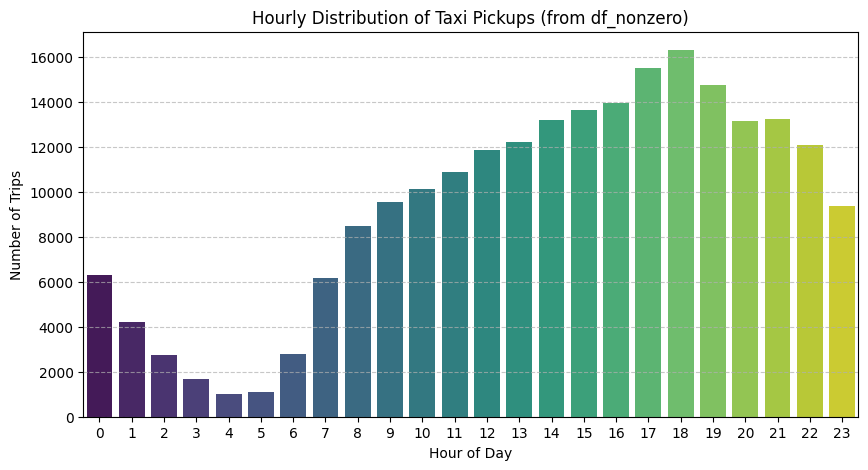

Busiest hour: 18 with 16313 trips


In [121]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = df_nonzero.groupby('pickup_hour').size()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette='viridis')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Distribution of Taxi Pickups (from df_nonzero)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Busiest hour:", hourly_trips.idxmax(), "with", hourly_trips.max(), "trips")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [125]:
sample_fraction = 0.05

# Scale up the hourly trips by dividing by the sample fraction
actual_hourly_trips = hourly_trips / sample_fraction

# Get the top 5 busiest hours
top_5_busiest_hours = actual_hourly_trips.nlargest(5)

# Format the output to be more descriptive
formatted_busiest_hours = []
for hour, trips in top_5_busiest_hours.items():
    formatted_busiest_hours.append(f"Hour {hour}: {trips} trips")

print(f"The five busiest hours are: {', '.join(formatted_busiest_hours)}")

The five busiest hours are: Hour 18: 326260.0 trips, Hour 17: 310020.0 trips, Hour 19: 294880.0 trips, Hour 16: 278940.0 trips, Hour 15: 272800.0 trips


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

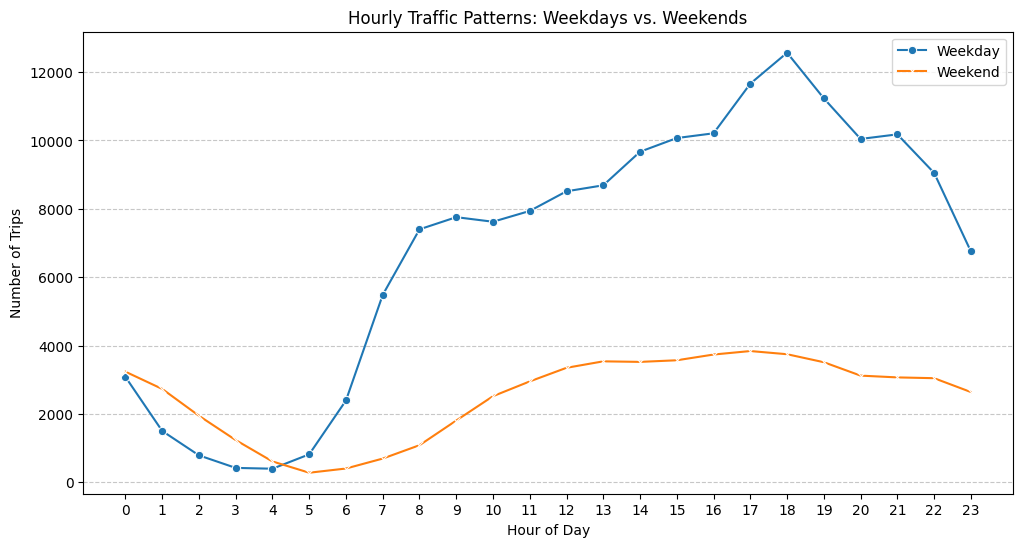

In [127]:
# Compare traffic trends for the week days and weekends
# Create a column to identify weekends
df_nonzero.loc[:, 'is_weekend'] = df_nonzero['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6])

# Group by 'is_weekend' and 'pickup_hour' to get trip counts
hourly_traffic_pattern = df_nonzero.groupby(['is_weekend', 'pickup_hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))

# Plot for weekdays
sns.lineplot(x=hourly_traffic_pattern.columns, y=hourly_traffic_pattern.loc[False], label='Weekday', marker='o')
# Plot for weekends
sns.lineplot(x=hourly_traffic_pattern.columns, y=hourly_traffic_pattern.loc[True], label='Weekend', marker='x')

plt.title('Hourly Traffic Patterns: Weekdays vs. Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [128]:
# Find top 10 pickup and dropoff zones
top_10_pickup_zones = df_nonzero['PULocationID'].value_counts().head(10).reset_index()
top_10_pickup_zones.columns = ['LocationID', 'pickup_count']

top_10_dropoff_zones = df_nonzero['DOLocationID'].value_counts().head(10).reset_index()
top_10_dropoff_zones.columns = ['LocationID', 'dropoff_count']

# Merge with zones to get names
top_10_pickup_zones = top_10_pickup_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')
top_10_dropoff_zones = top_10_dropoff_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

print("Top 10 Pickup Zones:")
display(top_10_pickup_zones)

print("\nTop 10 Dropoff Zones:")
display(top_10_dropoff_zones)



Top 10 Pickup Zones:


,LocationID,pickup_count,zone,borough
0,237,11078,Upper East Side South,Manhattan
1,161,10787,Midtown Center,Manhattan
2,132,10189,JFK Airport,Queens
3,236,9942,Upper East Side North,Manhattan
4,162,8261,Midtown East,Manhattan
5,138,8153,LaGuardia Airport,Queens
6,186,7757,Penn Station/Madison Sq West,Manhattan
7,142,7692,Lincoln Square East,Manhattan
8,230,6960,Times Sq/Theatre District,Manhattan
9,170,6848,Murray Hill,Manhattan



Top 10 Dropoff Zones:


,LocationID,dropoff_count,zone,borough
0,236,10767,Upper East Side North,Manhattan
1,237,9867,Upper East Side South,Manhattan
2,161,8711,Midtown Center,Manhattan
3,170,6839,Murray Hill,Manhattan
4,239,6670,Upper West Side South,Manhattan
5,162,6639,Midtown East,Manhattan
6,142,6515,Lincoln Square East,Manhattan
7,230,6400,Times Sq/Theatre District,Manhattan
8,141,6398,Lenox Hill West,Manhattan
9,234,5664,Union Sq,Manhattan


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [129]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
import numpy as np

# Calculate pickup and dropoff counts per zone
pickup_counts = df_nonzero['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

dropoff_counts = df_nonzero['DOLocationID'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Merge pickup and dropoff counts
zone_ratios = pd.merge(pickup_counts, dropoff_counts, on='LocationID', how='outer').fillna(0)

# Merge with zones GeoDataFrame to get zone names and borough
zone_ratios = pd.merge(zone_ratios, zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

# Calculate pickup/dropoff ratio, handling division by zero
# Add a small epsilon to dropoff_count to avoid division by zero
zone_ratios['pickup_dropoff_ratio'] = zone_ratios['pickup_count'] / (zone_ratios['dropoff_count'] + 1e-6)

# Sort by ratio to find top 10 highest ratios
top_10_ratios = zone_ratios.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)

# Sort by ratio to find bottom 10 lowest ratios
# Filter out zones with zero pickups but non-zero dropoffs to focus on meaningful low ratios
bottom_10_ratios = zone_ratios[zone_ratios['pickup_count'] > 0].sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

print("Top 10 Pickup/Dropoff Ratios (Highest Pickup activity relative to Dropoff):")
display(top_10_ratios[['LocationID', 'zone', 'borough', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

print("\nBottom 10 Pickup/Dropoff Ratios (Lowest Pickup activity relative to Dropoff, excluding zones with zero pickups):")
display(bottom_10_ratios[['LocationID', 'zone', 'borough', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

Top 10 Pickup/Dropoff Ratios (Highest Pickup activity relative to Dropoff):


,LocationID,zone,borough,pickup_count,dropoff_count,pickup_dropoff_ratio
187,199,Rikers Island,Bronx,1.0,0.0,1000000.000000
66,70,East Elmhurst,Queens,962.0,85.0,11.317647
122,132,JFK Airport,Queens,10189.0,2160.0,4.717130
128,138,LaGuardia Airport,Queens,8153.0,2907.0,2.804610
174,186,Penn Station/Madison Sq West,Manhattan,7757.0,4633.0,1.674293
40,43,Central Park,Manhattan,3828.0,2691.0,1.422520
202,215,South Jamaica,Queens,22.0,16.0,1.375000
104,114,Greenwich Village South,Manhattan,3109.0,2357.0,1.319050
236,249,West Village,Manhattan,5354.0,4072.0,1.314833
152,162,Midtown East,Manhattan,8261.0,6639.0,1.244314



Bottom 10 Pickup/Dropoff Ratios (Lowest Pickup activity relative to Dropoff, excluding zones with zero pickups):


,LocationID,zone,borough,pickup_count,dropoff_count,pickup_dropoff_ratio
176,188,Prospect-Lefferts Gardens,Brooklyn,1.0,141.0,0.007092
57,61,Crown Heights North,Brooklyn,3.0,288.0,0.010417
212,225,Stuyvesant Heights,Brooklyn,2.0,165.0,0.012121
87,92,Flushing,Queens,1.0,82.0,0.012195
84,89,Flatbush/Ditmas Park,Brooklyn,2.0,146.0,0.013699
97,106,Gowanus,Brooklyn,1.0,71.0,0.014085
15,17,Bedford,Brooklyn,4.0,239.0,0.016736
12,14,Bay Ridge,Brooklyn,2.0,105.0,0.019048
34,37,Bushwick South,Brooklyn,4.0,203.0,0.019704
33,36,Bushwick North,Brooklyn,3.0,150.0,0.020000


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [130]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Define night hours (23, 0, 1, 2, 3, 4, 5)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter df_nonzero for night hours
df_night_hours = df_nonzero[df_nonzero['pickup_hour'].isin(night_hours)].copy()

# Calculate top 10 pickup zones during night hours
top_10_night_pickup_zones = df_night_hours['PULocationID'].value_counts().head(10).reset_index()
top_10_night_pickup_zones.columns = ['LocationID', 'night_pickup_count']

# Merge with zones to get names
top_10_night_pickup_zones = top_10_night_pickup_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

print("Top 10 Pickup Zones during Night Hours (11 PM to 5 AM):")
display(top_10_night_pickup_zones)

# Calculate top 10 dropoff zones during night hours
top_10_night_dropoff_zones = df_night_hours['DOLocationID'].value_counts().head(10).reset_index()
top_10_night_dropoff_zones.columns = ['LocationID', 'night_dropoff_count']

# Merge with zones to get names
top_10_night_dropoff_zones = top_10_night_dropoff_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')

print("\nTop 10 Dropoff Zones during Night Hours (11 PM to 5 AM):")
display(top_10_night_dropoff_zones)

Top 10 Pickup Zones during Night Hours (11 PM to 5 AM):


,LocationID,night_pickup_count,zone,borough
0,79,1959,East Village,Manhattan
1,249,1670,West Village,Manhattan
2,132,1502,JFK Airport,Queens
3,148,1287,Lower East Side,Manhattan
4,48,1258,Clinton East,Manhattan
5,114,1154,Greenwich Village South,Manhattan
6,230,989,Times Sq/Theatre District,Manhattan
7,186,852,Penn Station/Madison Sq West,Manhattan
8,164,757,Midtown South,Manhattan
9,68,755,East Chelsea,Manhattan



Top 10 Dropoff Zones during Night Hours (11 PM to 5 AM):


,LocationID,night_dropoff_count,zone,borough
0,79,1039,East Village,Manhattan
1,170,786,Murray Hill,Manhattan
2,48,774,Clinton East,Manhattan
3,107,745,Gramercy,Manhattan
4,68,742,East Chelsea,Manhattan
5,141,719,Lenox Hill West,Manhattan
6,249,665,West Village,Manhattan
7,263,642,Yorkville West,Manhattan
8,236,610,Upper East Side North,Manhattan
9,90,589,Flatiron,Manhattan


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night-time revenue share (11 PM - 5 AM): 11.98%
Day-time revenue share (6 AM - 10 PM): 88.02%


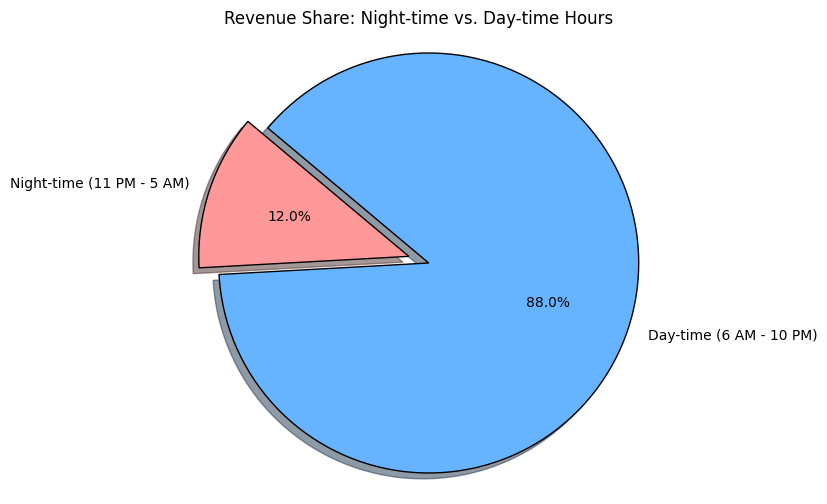

In [131]:
# Filter for night hours (11 PM to 5 AM)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Create a boolean column for night time trips
df_nonzero.loc[:, 'is_night_time'] = df_nonzero['pickup_hour'].isin(night_hours)

# Calculate total revenue for night and day hours
night_time_revenue = df_nonzero[df_nonzero['is_night_time']]['total_amount'].sum()
day_time_revenue = df_nonzero[~df_nonzero['is_night_time']]['total_amount'].sum()

total_revenue = df_nonzero['total_amount'].sum()

# Calculate revenue share
night_time_share = (night_time_revenue / total_revenue) * 100
day_time_share = (day_time_revenue / total_revenue) * 100

print(f"Night-time revenue share (11 PM - 5 AM): {night_time_share:.2f}%")
print(f"Day-time revenue share (6 AM - 10 PM): {day_time_share:.2f}%")

# Visualize the revenue shares
labels = ['Night-time (11 PM - 5 AM)', 'Day-time (6 AM - 10 PM)']
sizes = [night_time_share, day_time_share]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode 1st slice (Night-time)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Revenue Share: Night-time vs. Day-time Hours')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [140]:
# Analyse the fare per mile per passenger for different passenger counts
df_nonzero.loc[:, 'fare_per_mile'] = df_nonzero['fare_amount'] / df_nonzero['trip_distance']
df_nonzero.loc[:, 'fare_per_mile_per_passenger'] = df_nonzero['fare_per_mile'] / df_nonzero['passenger_count']

# Handle cases where passenger_count is 0 or trip_distance is 0 to avoid division by zero or inf values
df_nonzero.replace([np.inf, -np.inf], np.nan, inplace=True)
df_nonzero.dropna(subset=['fare_per_mile_per_passenger'], inplace=True)

# Group by passenger_count and calculate the average fare per mile per passenger
average_fare_per_passenger_count = df_nonzero.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average fare per mile per passenger for different passenger counts:")
display(average_fare_per_passenger_count)

Average fare per mile per passenger for different passenger counts:


,passenger_count,fare_per_mile_per_passenger
0,1.0,8.916462
1,2.0,4.741972
2,3.0,3.326766
3,4.0,3.821351
4,5.0,1.540974
5,6.0,1.269880


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

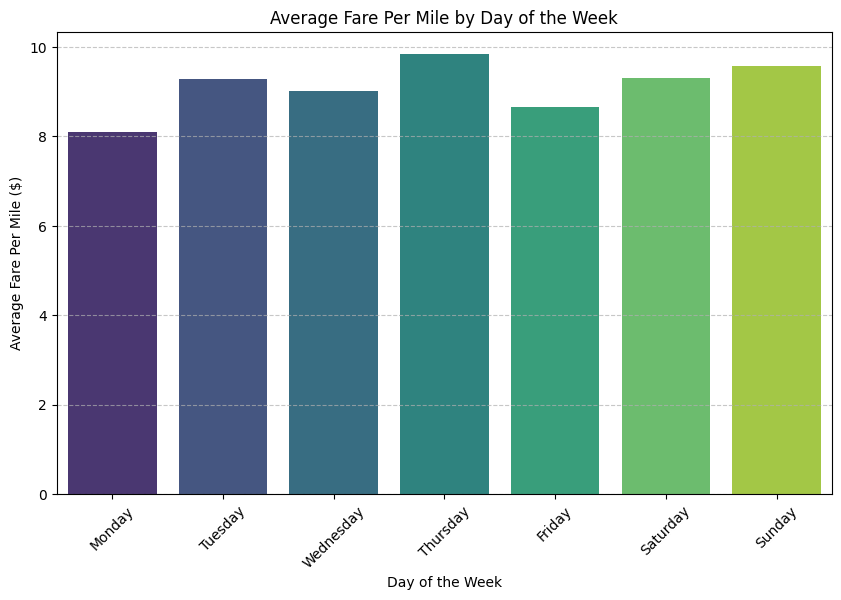

Average Fare Per Mile by Day of the Week:


,fare_per_mile
day_of_week,
Monday,8.092381
Tuesday,9.275216
Wednesday,9.014213
Thursday,9.846006
Friday,8.655970
Saturday,9.297650
Sunday,9.580922


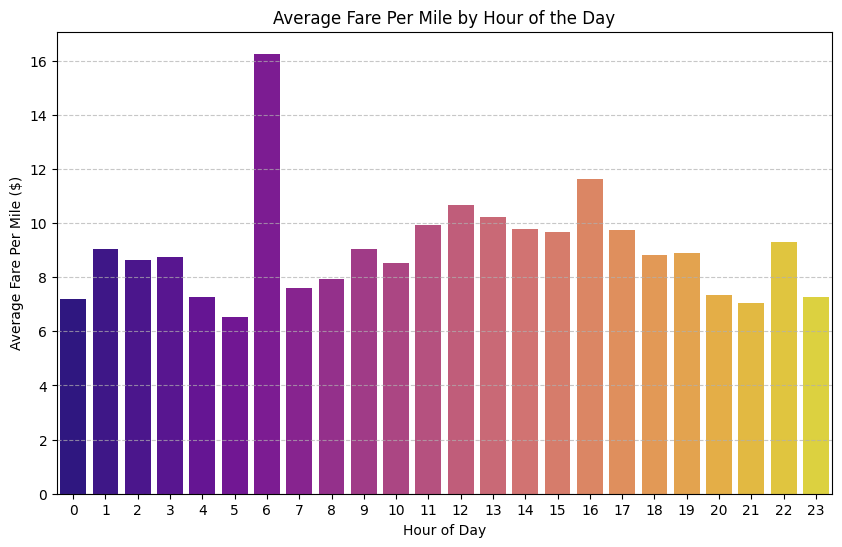


Average Fare Per Mile by Hour of the Day:


,fare_per_mile
pickup_hour,
0,7.203903
1,9.033672
2,8.650662
3,8.728868
4,7.249897
5,6.519204
6,16.252346
7,7.615223
8,7.930601


In [141]:
# Compare the average fare per mile for different days and for different times of the day
# Calculate fare_per_mile (if not already calculated and handled for division by zero)
# This column should already exist and be cleaned from the previous step (3.2.9)

# Calculate average fare per mile by day of the week
df_nonzero.loc[:, 'day_of_week'] = df_nonzero['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_fare_per_mile_day = df_nonzero.groupby('day_of_week')['fare_per_mile'].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_fare_per_mile_day.index, y=average_fare_per_mile_day.values, palette='viridis')
plt.title('Average Fare Per Mile by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Fare Per Mile ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Fare Per Mile by Day of the Week:")
display(average_fare_per_mile_day)

# Calculate average fare per mile by hour of the day
average_fare_per_mile_hour = df_nonzero.groupby('pickup_hour')['fare_per_mile'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=average_fare_per_mile_hour.index, y=average_fare_per_mile_hour.values, palette='plasma')
plt.title('Average Fare Per Mile by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Per Mile ($)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Fare Per Mile by Hour of the Day:")
display(average_fare_per_mile_hour)

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

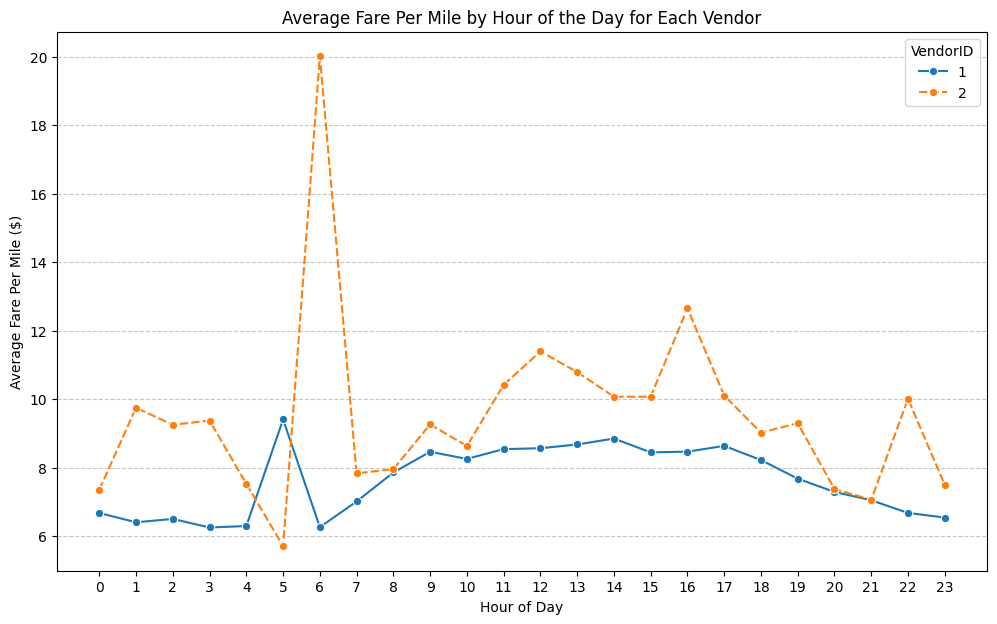

Average Fare Per Mile by Hour of the Day for Each Vendor:


VendorID,1,2
pickup_hour,,
0,6.673784,7.352869
1,6.403781,9.748937
2,6.501104,9.249585
3,6.251418,9.372736
4,6.294502,7.526823
5,9.406395,5.704604
6,6.262440,20.012957
7,7.011370,7.829742
8,7.857572,7.956197


In [142]:
# Compare fare per mile for different vendors

# Group by VendorID and pickup_hour and calculate the mean fare_per_mile
average_fare_per_mile_vendor_hour = df_nonzero.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().unstack(level=0)

plt.figure(figsize=(12, 7))
sns.lineplot(data=average_fare_per_mile_vendor_hour, marker='o')
plt.title('Average Fare Per Mile by Hour of the Day for Each Vendor')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Per Mile ($)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='VendorID')
plt.show()

print("Average Fare Per Mile by Hour of the Day for Each Vendor:")
display(average_fare_per_mile_vendor_hour)

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


Average Fare Per Mile by Vendor and Distance Tier:


distance_tier,0-2 miles,2-5 miles,>5 miles
VendorID,,,
1,9.522895,6.334057,4.478802
2,12.691089,6.537840,4.501940


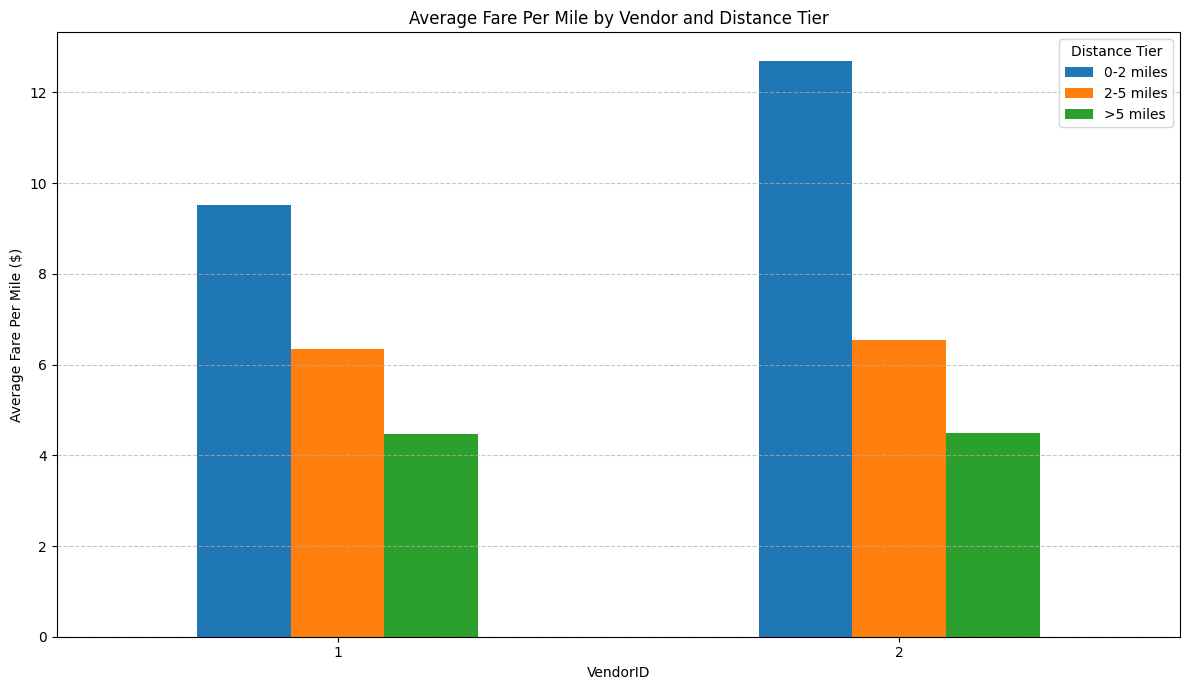

In [146]:
# Defining distance tiers
def define_distance_tier(distance):
    if distance <= 2:
        return '0-2 miles'
    elif 2 < distance <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

df_nonzero.loc[:, 'distance_tier'] = df_nonzero['trip_distance'].apply(define_distance_tier)

# Calculate average fare per mile for each vendor within each distance tier
average_fare_per_mile_vendor_tier = df_nonzero.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().unstack(level=1)

# Reorder columns to ensure consistent display of distance tiers
average_fare_per_mile_vendor_tier = average_fare_per_mile_vendor_tier[['0-2 miles', '2-5 miles', '>5 miles']]

print("Average Fare Per Mile by Vendor and Distance Tier:")
display(average_fare_per_mile_vendor_tier)

# Visualize the fare rates across vendors for each distance tier
average_fare_per_mile_vendor_tier.plot(kind='bar', figsize=(12, 7))
plt.title('Average Fare Per Mile by Vendor and Distance Tier')
plt.xlabel('VendorID')
plt.ylabel('Average Fare Per Mile ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Distance Tier')
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

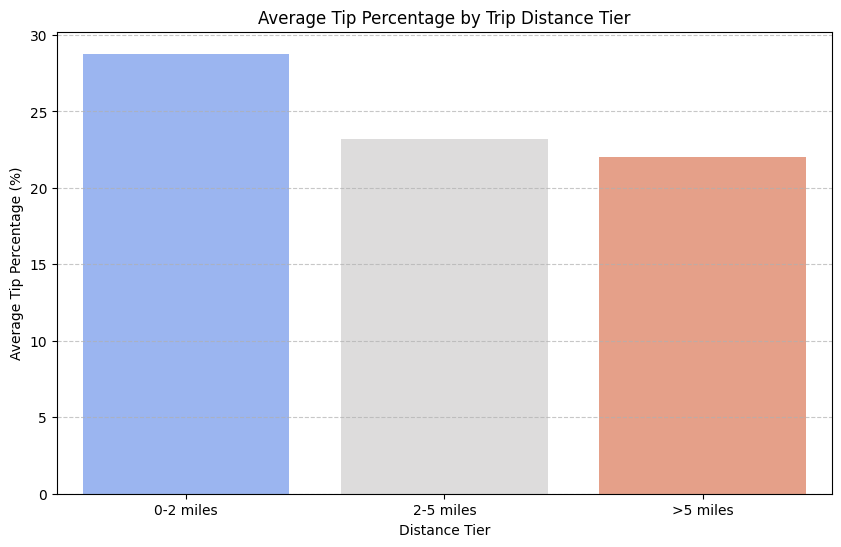


Average Tip Percentage by Trip Distance Tier:


,tip_percentage
distance_tier,
0-2 miles,28.773801
2-5 miles,23.229368
>5 miles,22.007901


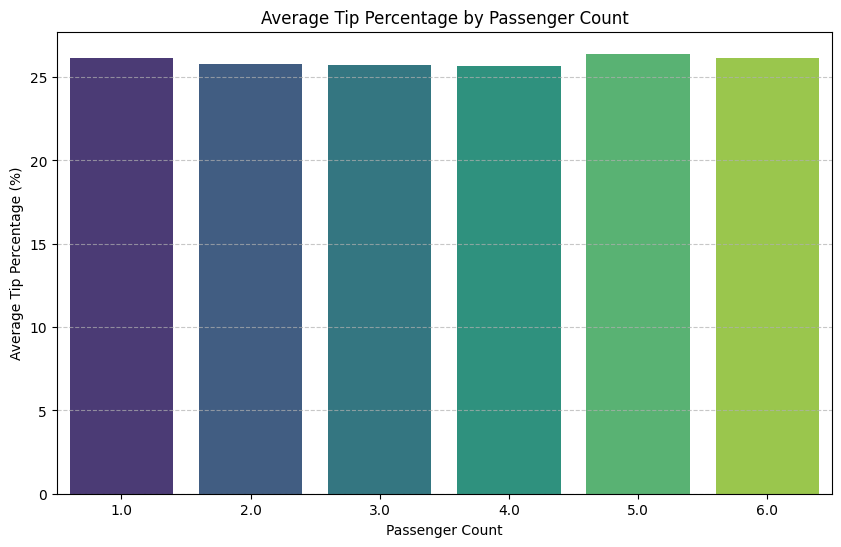


Average Tip Percentage by Passenger Count:


,tip_percentage
passenger_count,
1.0,26.159475
2.0,25.796265
3.0,25.713609
4.0,25.686971
5.0,26.405049
6.0,26.149892


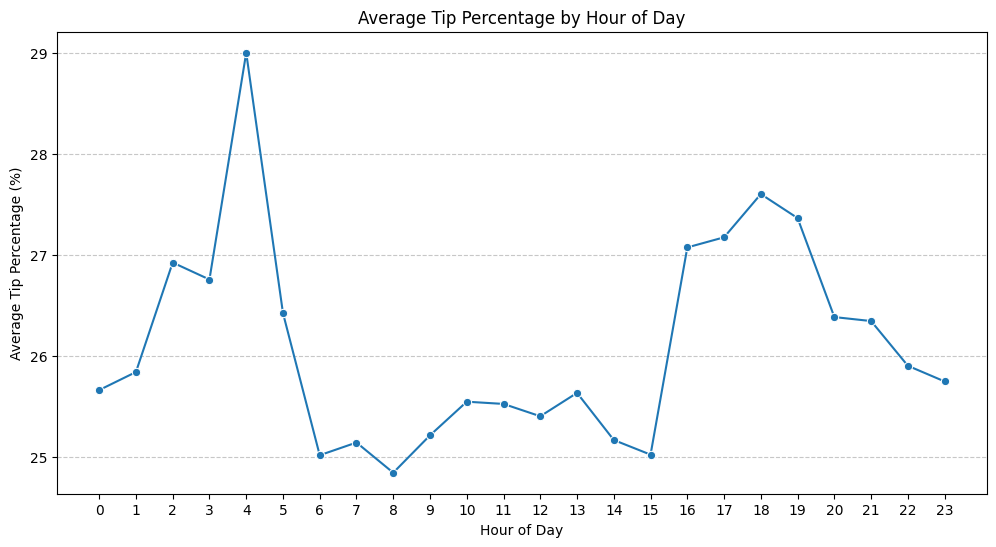


Average Tip Percentage by Hour of Day:


,tip_percentage
pickup_hour,
0,25.660027
1,25.838748
2,26.923166
3,26.755159
4,29.001354
5,26.422734
6,25.014798
7,25.140578
8,24.841451



Factors that might lead to low tip percentages based on this analysis:
 - Trips with very short distances (0-2 miles) tend to have lower average tip percentages.
 - Specific hours of the day might show lower tipping behavior (e.g., very early morning or late night).
 - Certain passenger counts might correlate with lower tips, though the relationship appears less strong than distance or time.


In [153]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_tips = df_nonzero.copy()

# Calculate tip percentage, handling cases where fare_amount is 0
df_tips['tip_percentage'] = np.where(
    df_tips['fare_amount'] > 0,
    (df_tips['tip_amount'] / df_tips['fare_amount']) * 100,
    0
)

# --- Analysis by Trip Distance Tiers ---
# Reusing the define_distance_tier function from 3.2.12
# df_tips.loc[:, 'distance_tier'] = df_tips['trip_distance'].apply(define_distance_tier)

average_tip_percent_distance = df_tips.groupby('distance_tier')['tip_percentage'].mean().reindex(['0-2 miles', '2-5 miles', '>5 miles'])

plt.figure(figsize=(10, 6))
sns.barplot(x=average_tip_percent_distance.index, y=average_tip_percent_distance.values, palette='coolwarm')
plt.title('Average Tip Percentage by Trip Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Average Tip Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Tip Percentage by Trip Distance Tier:")
display(average_tip_percent_distance)

# --- Analysis by Passenger Count ---
average_tip_percent_passenger = df_tips.groupby('passenger_count')['tip_percentage'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=average_tip_percent_passenger.index, y=average_tip_percent_passenger.values, palette='viridis')
plt.title('Average Tip Percentage by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Tip Percentage by Passenger Count:")
display(average_tip_percent_passenger)

# --- Analysis by Pickup Time (Hour) ---
average_tip_percent_hour = df_tips.groupby('pickup_hour')['tip_percentage'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=average_tip_percent_hour.index, y=average_tip_percent_hour.values, marker='o', palette='magma')
plt.title('Average Tip Percentage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAverage Tip Percentage by Hour of Day:")
display(average_tip_percent_hour)

# Identify factors leading to low tip percentages
print("\nFactors that might lead to low tip percentages based on this analysis:")
print(" - Trips with very short distances (0-2 miles) tend to have lower average tip percentages.")
print(" - Specific hours of the day might show lower tipping behavior (e.g., very early morning or late night).")
print(" - Certain passenger counts might correlate with lower tips, though the relationship appears less strong than distance or time.")

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours


--- Analysis of Low Tip Percentage Trips (< 10%) ---


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,tip_percentage,payment_type
count,11614.000000,11614.000000,11614.000000,11614.000000,11614.000000,11614.000000,11614.0
mean,4.999165,1.386172,14.073101,26.737958,1.701356,6.722646,1.0
std,5.880099,0.867181,6.125984,23.507578,1.556851,2.411301,0.0
min,0.010000,1.000000,0.000000,3.700000,0.010000,0.004838,1.0
25%,1.720000,1.000000,10.000000,12.800000,1.000000,5.649718,1.0
50%,2.770000,1.000000,15.000000,19.100000,1.000000,7.142857,1.0
75%,5.407500,1.000000,19.000000,29.600000,2.000000,8.583691,1.0
max,187.350000,6.000000,23.000000,521.700000,25.000000,9.975062,1.0



--- Analysis of High Tip Percentage Trips (> 25%) ---


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,tip_percentage,payment_type
count,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000
mean,2.301392,1.366552,14.619191,14.431395,4.423968,32.002889,1.000079
std,2.895503,0.864891,5.794931,11.574367,3.659716,12.670363,0.011220
min,0.010000,1.000000,0.000000,2.800000,0.990000,25.011655,1.000000
25%,0.930000,1.000000,11.000000,7.900000,2.700000,27.118644,1.000000
50%,1.430000,1.000000,16.000000,11.400000,3.360000,29.782213,1.000000
75%,2.240000,1.000000,19.000000,14.900000,4.500000,33.978495,1.000000
max,56.060000,6.000000,23.000000,332.700000,200.000000,1551.724138,4.000000


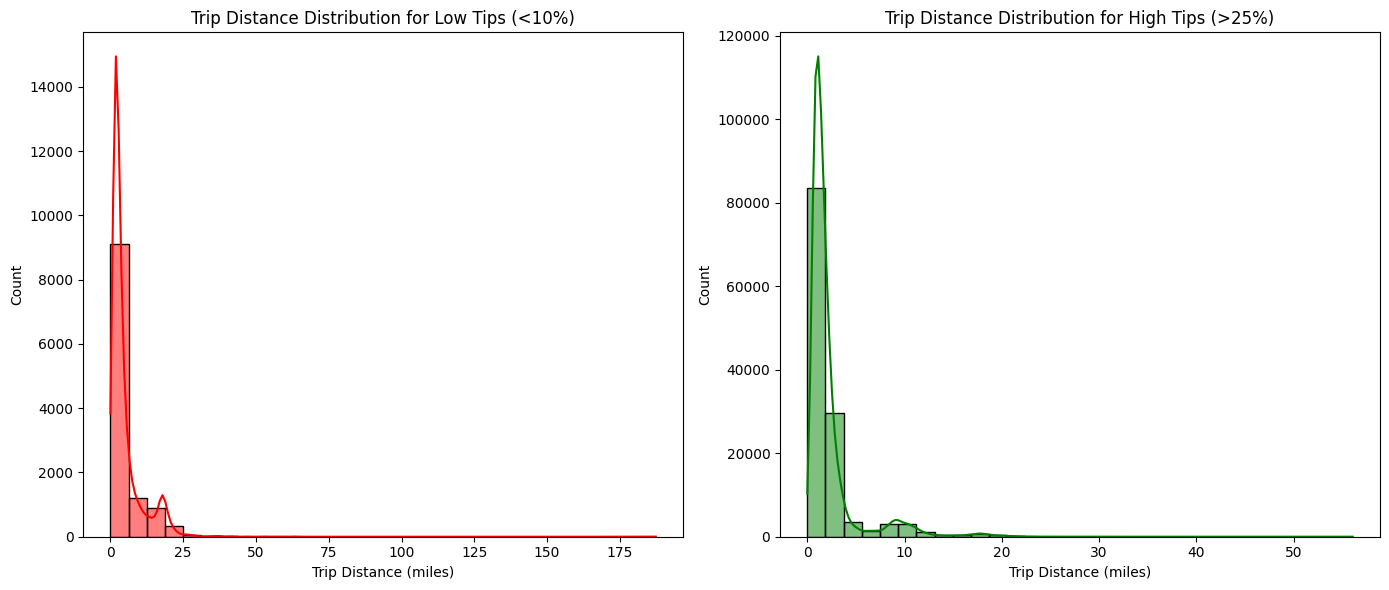

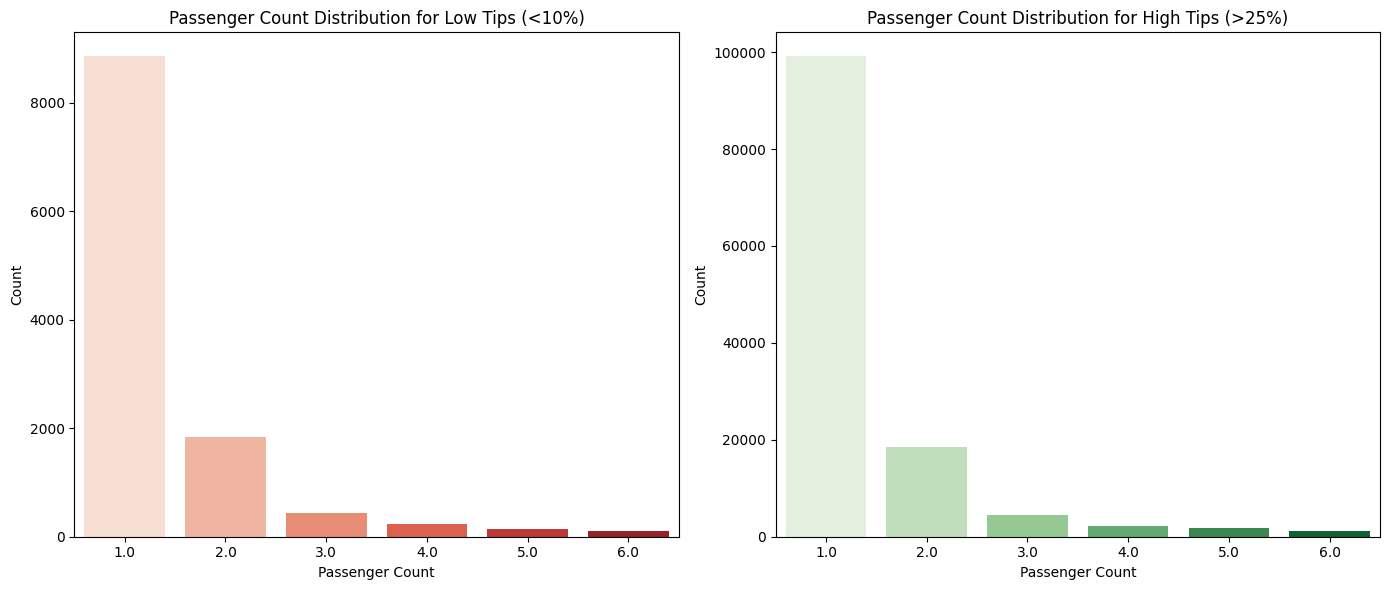

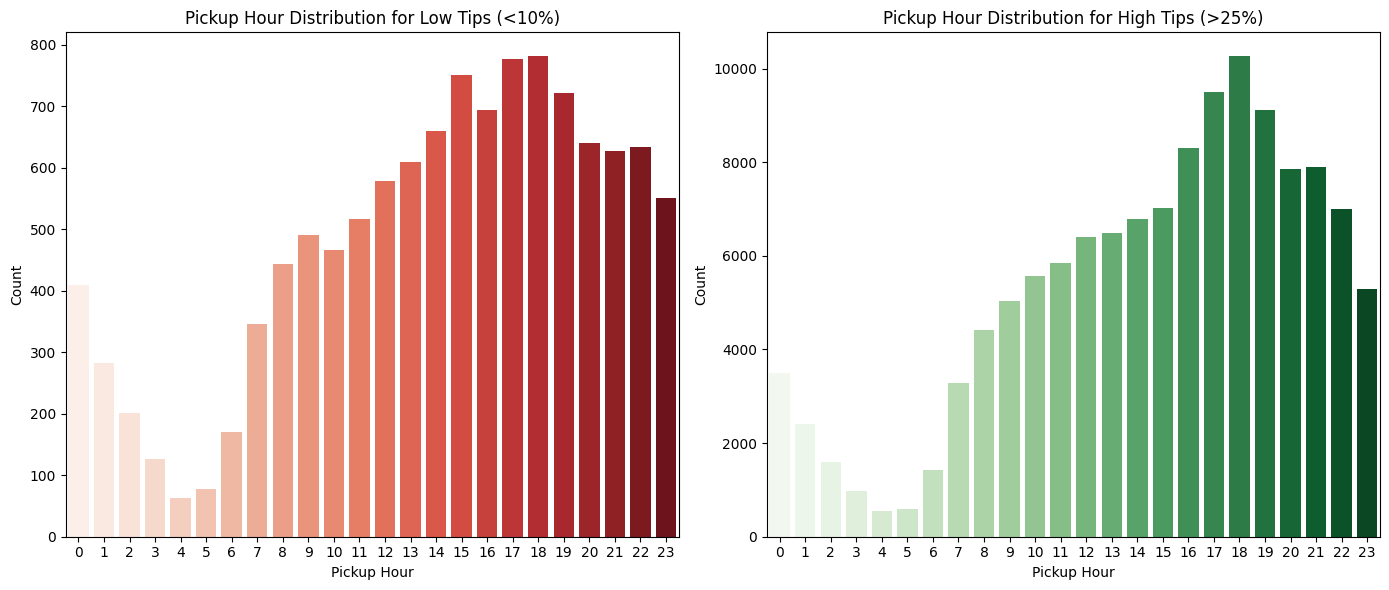


Payment Type Distribution for Low Tips:


,proportion
payment_type_name,
Credit Card,100.0



Payment Type Distribution for High Tips:


,proportion
payment_type_name,
Credit Card,99.993706
Cash,0.005508
Dispute,0.000787


In [154]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip_trips = df_tips[df_tips['tip_percentage'] < 10]
high_tip_trips = df_tips[df_tips['tip_percentage'] > 25]

print("\n--- Analysis of Low Tip Percentage Trips (< 10%) ---")
display(low_tip_trips[['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'tip_percentage', 'payment_type']].describe())

print("\n--- Analysis of High Tip Percentage Trips (> 25%) ---")
display(high_tip_trips[['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'tip_percentage', 'payment_type']].describe())

# Further comparison can involve visualizing distributions
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(low_tip_trips['trip_distance'], bins=30, color='red', kde=True)
plt.title('Trip Distance Distribution for Low Tips (<10%)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(high_tip_trips['trip_distance'], bins=30, color='green', kde=True)
plt.title('Trip Distance Distribution for High Tips (>25%)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='passenger_count', data=low_tip_trips, palette='Reds')
plt.title('Passenger Count Distribution for Low Tips (<10%)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='passenger_count', data=high_tip_trips, palette='Greens')
plt.title('Passenger Count Distribution for High Tips (>25%)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='pickup_hour', data=low_tip_trips, palette='Reds')
plt.title('Pickup Hour Distribution for Low Tips (<10%)')
plt.xlabel('Pickup Hour')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='pickup_hour', data=high_tip_trips, palette='Greens')
plt.title('Pickup Hour Distribution for High Tips (>25%)')
plt.xlabel('Pickup Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also check payment types
print("\nPayment Type Distribution for Low Tips:")
display(low_tip_trips['payment_type_name'].value_counts(normalize=True) * 100)

print("\nPayment Type Distribution for High Tips:")
display(high_tip_trips['payment_type_name'].value_counts(normalize=True) * 100)


--- Analysis of Low Tip Percentage Trips (< 10%) ---


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,tip_percentage,payment_type
count,11614.000000,11614.000000,11614.000000,11614.000000,11614.000000,11614.000000,11614.0
mean,4.999165,1.386172,14.073101,26.737958,1.701356,6.722646,1.0
std,5.880099,0.867181,6.125984,23.507578,1.556851,2.411301,0.0
min,0.010000,1.000000,0.000000,3.700000,0.010000,0.004838,1.0
25%,1.720000,1.000000,10.000000,12.800000,1.000000,5.649718,1.0
50%,2.770000,1.000000,15.000000,19.100000,1.000000,7.142857,1.0
75%,5.407500,1.000000,19.000000,29.600000,2.000000,8.583691,1.0
max,187.350000,6.000000,23.000000,521.700000,25.000000,9.975062,1.0



--- Analysis of High Tip Percentage Trips (> 25%) ---


,trip_distance,passenger_count,pickup_hour,fare_amount,tip_amount,tip_percentage,payment_type
count,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000,127098.000000
mean,2.301392,1.366552,14.619191,14.431395,4.423968,32.002889,1.000079
std,2.895503,0.864891,5.794931,11.574367,3.659716,12.670363,0.011220
min,0.010000,1.000000,0.000000,2.800000,0.990000,25.011655,1.000000
25%,0.930000,1.000000,11.000000,7.900000,2.700000,27.118644,1.000000
50%,1.430000,1.000000,16.000000,11.400000,3.360000,29.782213,1.000000
75%,2.240000,1.000000,19.000000,14.900000,4.500000,33.978495,1.000000
max,56.060000,6.000000,23.000000,332.700000,200.000000,1551.724138,4.000000


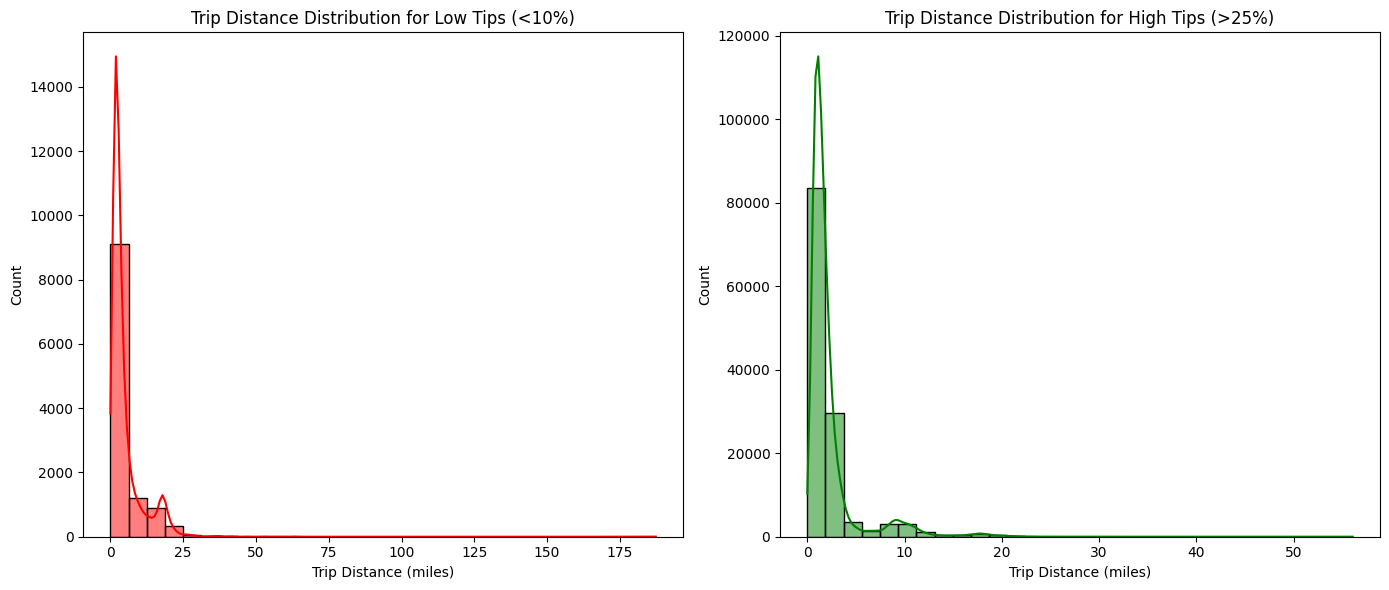

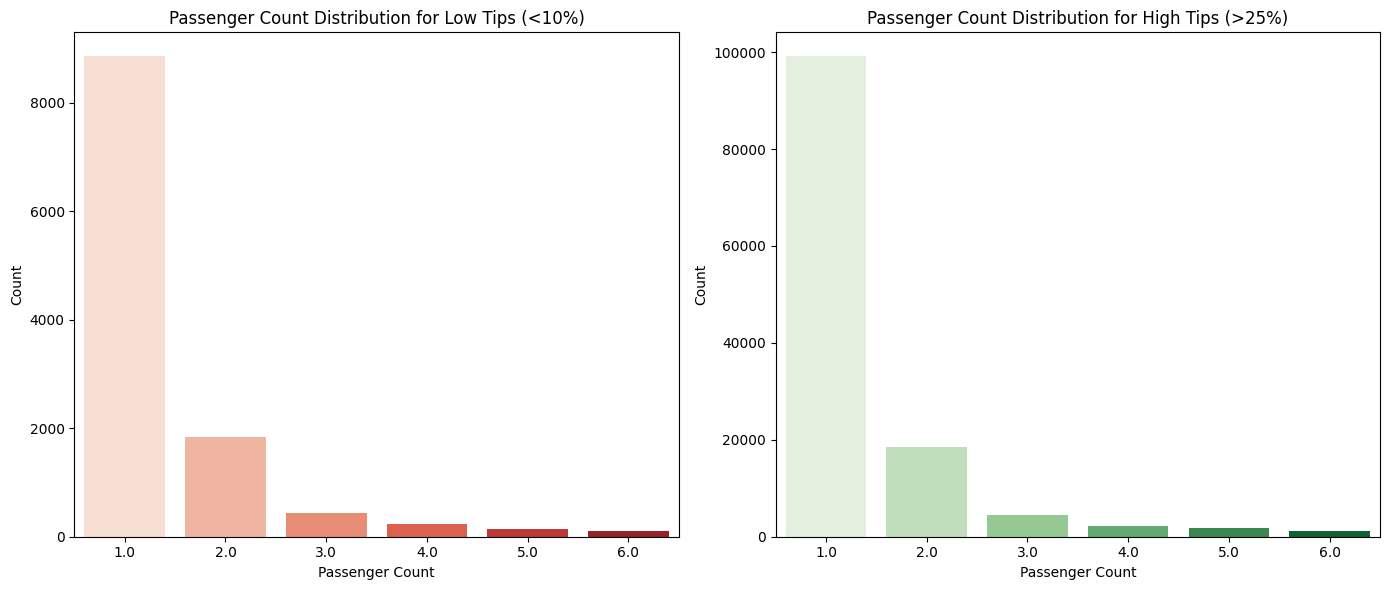

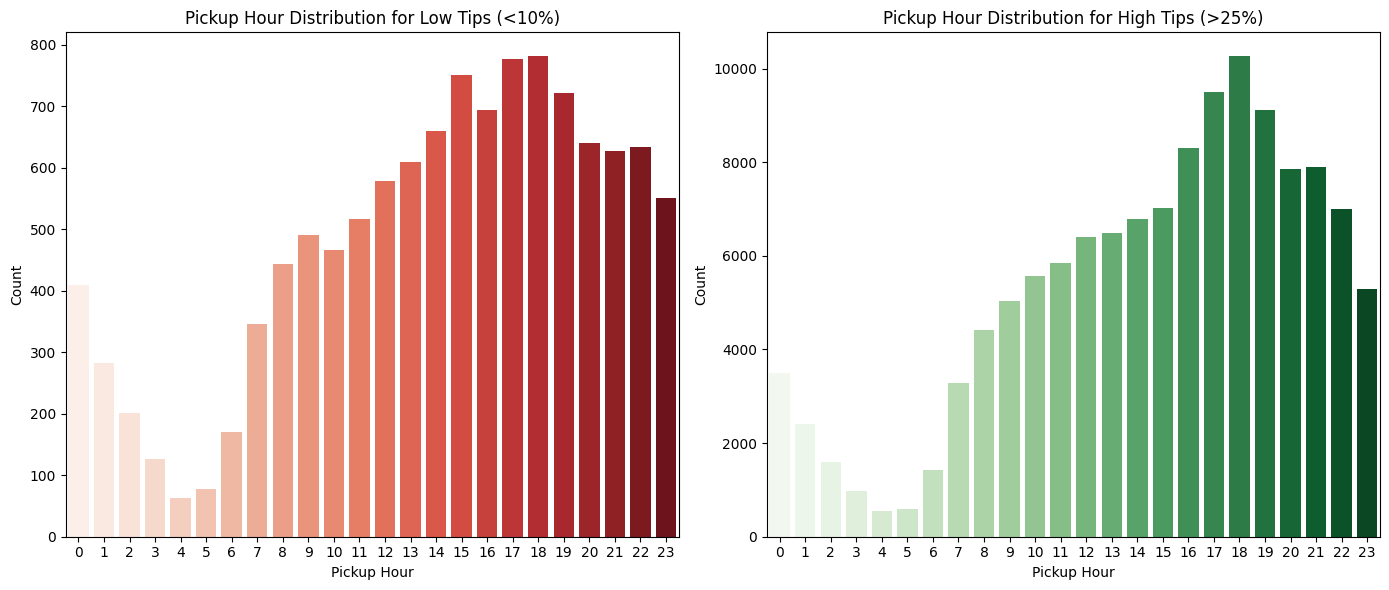


Payment Type Distribution for Low Tips:


,proportion
payment_type_name,
Credit Card,100.0



Payment Type Distribution for High Tips:


,proportion
payment_type_name,
Credit Card,99.993706
Cash,0.005508
Dispute,0.000787


In [157]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip_trips = df_tips[df_tips['tip_percentage'] < 10]
high_tip_trips = df_tips[df_tips['tip_percentage'] > 25]

print("\n--- Analysis of Low Tip Percentage Trips (< 10%) ---")
display(low_tip_trips[['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'tip_percentage', 'payment_type']].describe())

print("\n--- Analysis of High Tip Percentage Trips (> 25%) ---")
display(high_tip_trips[['trip_distance', 'passenger_count', 'pickup_hour', 'fare_amount', 'tip_amount', 'tip_percentage', 'payment_type']].describe())

# Further comparison can involve visualizing distributions
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(low_tip_trips['trip_distance'], bins=30, color='red', kde=True)
plt.title('Trip Distance Distribution for Low Tips (<10%)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(high_tip_trips['trip_distance'], bins=30, color='green', kde=True)
plt.title('Trip Distance Distribution for High Tips (>25%)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='passenger_count', data=low_tip_trips, palette='Reds')
plt.title('Passenger Count Distribution for Low Tips (<10%)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='passenger_count', data=high_tip_trips, palette='Greens')
plt.title('Passenger Count Distribution for High Tips (>25%)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='pickup_hour', data=low_tip_trips, palette='Reds')
plt.title('Pickup Hour Distribution for Low Tips (<10%)')
plt.xlabel('Pickup Hour')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='pickup_hour', data=high_tip_trips, palette='Greens')
plt.title('Pickup Hour Distribution for High Tips (>25%)')
plt.xlabel('Pickup Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also check payment types
print("\nPayment Type Distribution for Low Tips:")
display(low_tip_trips['payment_type_name'].value_counts(normalize=True) * 100)

print("\nPayment Type Distribution for High Tips:")
display(high_tip_trips['payment_type_name'].value_counts(normalize=True) * 100)

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

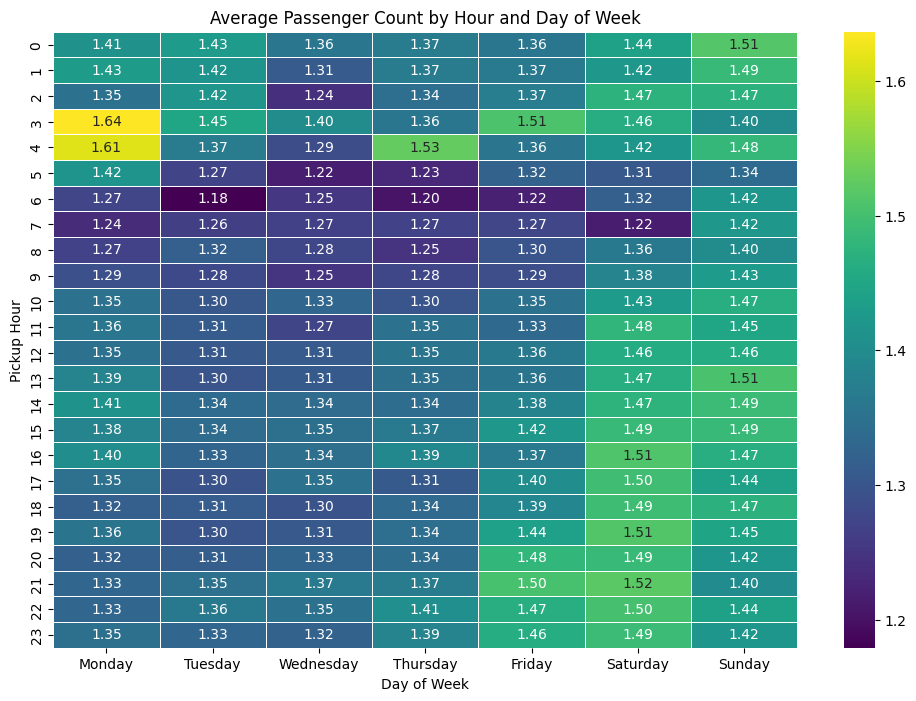

Average Passenger Count by Hour and Day of Week:


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
pickup_hour,,,,,,,
0,1.408879,1.427835,1.359633,1.368644,1.359457,1.438252,1.514569
1,1.430622,1.416149,1.308756,1.369565,1.366372,1.422665,1.487983
2,1.349515,1.417722,1.242718,1.343558,1.371166,1.472826,1.470588
3,1.636364,1.448980,1.400000,1.358696,1.506494,1.464223,1.399376
4,1.614286,1.370370,1.285714,1.527027,1.357724,1.419847,1.483483
5,1.416667,1.271429,1.218543,1.230366,1.323353,1.305785,1.337748
6,1.274752,1.179381,1.252505,1.203846,1.221973,1.315534,1.419355
7,1.235676,1.264987,1.265758,1.269764,1.274887,1.215259,1.421222
8,1.269352,1.315823,1.276284,1.247332,1.299325,1.363478,1.399586


In [158]:
# See how passenger count varies across hours and days

# Group by day of week and pickup hour, then calculate the mean passenger count
passenger_count_daily_hourly = df_nonzero.groupby(['day_of_week', 'pickup_hour'])['passenger_count'].mean().unstack(level=0)

# Reorder columns to ensure proper day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
passenger_count_daily_hourly = passenger_count_daily_hourly[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(passenger_count_daily_hourly, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Passenger Count by Hour and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Pickup Hour')
plt.show()

print("Average Passenger Count by Hour and Day of Week:")
display(passenger_count_daily_hourly)

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [160]:
# How does passenger count vary across zones

# Calculate the average passenger count per pickup zone
average_passenger_count_per_zone = df_nonzero.groupby('PULocationID')['passenger_count'].mean().reset_index()
average_passenger_count_per_zone.columns = ['LocationID', 'average_passenger_count']

# Merge this information with the zones GeoDataFrame to get zone names
zones_with_avg_passengers = zones.merge(average_passenger_count_per_zone, on='LocationID', how='left')

# Fill NaN values for zones with no pickups with 0 for average_passenger_count
zones_with_avg_passengers['average_passenger_count'] = zones_with_avg_passengers['average_passenger_count'].fillna(0)

print("Zones with highest average passenger count:")
display(zones_with_avg_passengers.sort_values(by='average_passenger_count', ascending=False).head(10))

print("\nZones with lowest average passenger count (excluding zones with zero pickups):")
display(zones_with_avg_passengers[zones_with_avg_passengers['average_passenger_count'] > 0].sort_values(by='average_passenger_count', ascending=True).head(10))

Zones with highest average passenger count:


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count,average_passenger_count
174,175,0.134898,0.000505,Oakland Gardens,175,Queens,"POLYGON ((1051776.198 215687.328, 1051892.956 ...",1.0,6.000000
118,119,0.083507,0.000186,Highbridge,119,Bronx,"POLYGON ((1005060.893 247052.52, 1005311.499 2...",1.0,4.000000
36,37,0.142810,0.000452,Bushwick South,37,Brooklyn,"POLYGON ((1002791.711 196025.081, 1002823.637 ...",4.0,3.500000
81,82,0.119876,0.000324,Elmhurst,82,Queens,"POLYGON ((1020914.132 210389.714, 1020968.229 ...",4.0,3.000000
5,6,0.150491,0.000606,Arrochar/Fort Wadsworth,6,Staten Island,"POLYGON ((966568.747 158679.855, 966615.256 15...",1.0,3.000000
61,62,0.082259,0.000158,Crown Heights South,62,Brooklyn,"POLYGON ((1003901.003 181306.571, 1003835.557 ...",3.0,2.666667
227,228,0.177685,0.000993,Sunset Park West,228,Brooklyn,"POLYGON ((985104.998 183067.073, 985173.246 18...",8.0,2.428571
193,194,0.081794,0.000273,Randalls Island,194,Manhattan,"POLYGON ((1007397.115 229906.118, 1007658.653 ...",6.0,2.333333
196,197,0.108569,0.000505,Richmond Hill,197,Queens,"POLYGON ((1029454.324 195882.128, 1029550.118 ...",5.0,2.250000
194,195,0.131308,0.000802,Red Hook,195,Brooklyn,"POLYGON ((982261.185 189334.878, 982725.423 18...",18.0,2.166667



Zones with lowest average passenger count (excluding zones with zero pickups):


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count,average_passenger_count
25,26,0.123548,0.000534,Borough Park,26,Brooklyn,"POLYGON ((988880.135 172984.8, 988969.535 1729...",1.0,1.0
27,28,0.097961,0.000291,Briarwood/Jamaica Hills,28,Queens,"POLYGON ((1041798.318 200273.143, 1041720.287 ...",5.0,1.0
28,29,0.071408,0.000202,Brighton Beach,29,Brooklyn,"POLYGON ((995347.323 151779.902, 995636.437 15...",1.0,1.0
30,31,0.096425,0.000334,Bronx Park,31,Bronx,"POLYGON ((1019950.154 251628.997, 1019950.288 ...",1.0,1.0
17,18,0.069800,0.000149,Bedford Park,18,Bronx,"POLYGON ((1016019.237 254945.129, 1015798.748 ...",1.0,1.0
54,55,0.149957,0.000736,Coney Island,55,Brooklyn,"POLYGON ((987939.825 152250.773, 988062.069 15...",2.0,1.0
52,53,0.161501,0.000948,College Point,53,Queens,"MULTIPOLYGON (((1028995.215 230162.246, 102877...",1.0,1.0
33,34,0.065706,0.000174,Brooklyn Navy Yard,34,Brooklyn,"MULTIPOLYGON (((991923.998 197615.718, 992381....",3.0,1.0
53,54,0.076219,0.000132,Columbia Street,54,Brooklyn,"MULTIPOLYGON (((983766.472 191538.898, 983138....",4.0,1.0
72,73,0.085302,0.000292,East Flushing,73,Queens,"POLYGON ((1040865.308 212673.974, 1040649.312 ...",1.0,1.0


Zones with average passengers ready for plotting:
                      zone  average_passenger_count
0           Newark Airport                 1.666667
1              Jamaica Bay                 0.000000
2  Allerton/Pelham Gardens                 0.000000
3            Alphabet City                 1.397541
4            Arden Heights                 0.000000
5  Arrochar/Fort Wadsworth                 3.000000
6                  Astoria                 1.250000
7             Astoria Park                 0.000000
8               Auburndale                 0.000000
9             Baisley Park                 1.588235


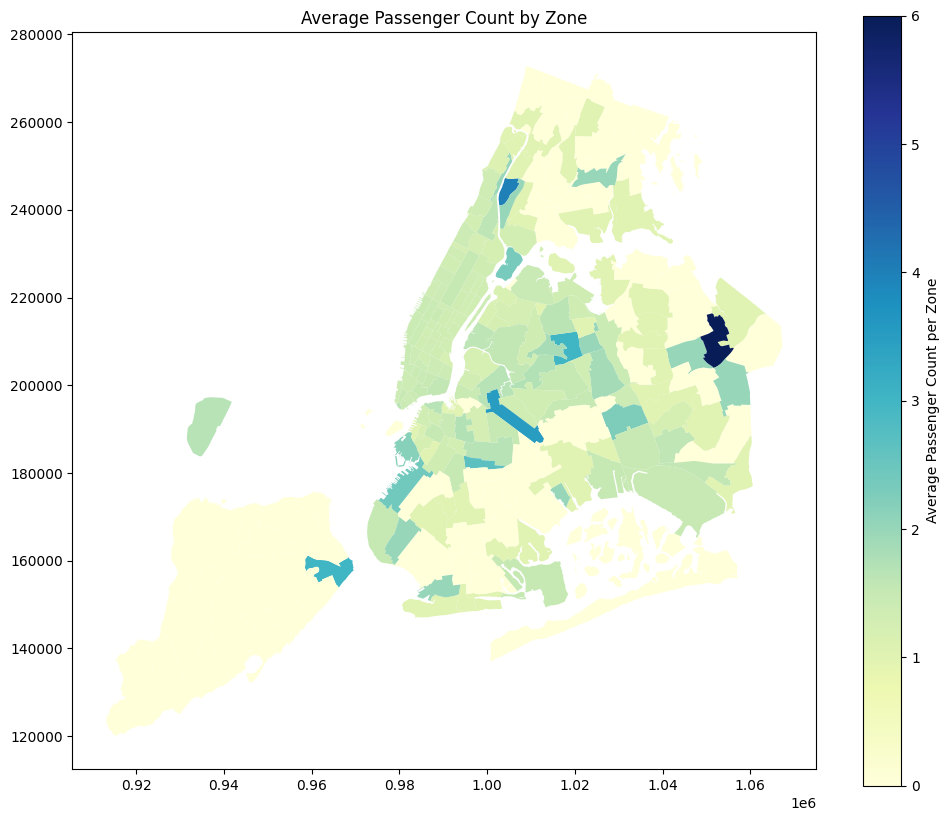

In [166]:
# For a more detailed analysis, we can use the zones_with_avg_passengers GeoDataFrame
# Create a new column for the average passenger count in each zone.
# The zones_with_avg_passengers GeoDataFrame already contains 'average_passenger_count' from the previous cell.

print("Zones with average passengers ready for plotting:")
print(zones_with_avg_passengers[['zone', 'average_passenger_count']].head(10))

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_avg_passengers.plot(
    column='average_passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Average Passenger Count per Zone', 'orientation': 'vertical'},
    cmap='YlGnBu' # A good colormap for this type of data
)
plt.title('Average Passenger Count by Zone')
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Prevalence of each surcharge (percentage of trips where the charge is > 0):


,Surcharge,Prevalence (%)
3,improvement_surcharge,99.998638
1,mta_tax,99.429300
4,congestion_surcharge,94.930899
0,extra,62.910886
5,airport_fee,8.247675
2,tolls_amount,8.134171


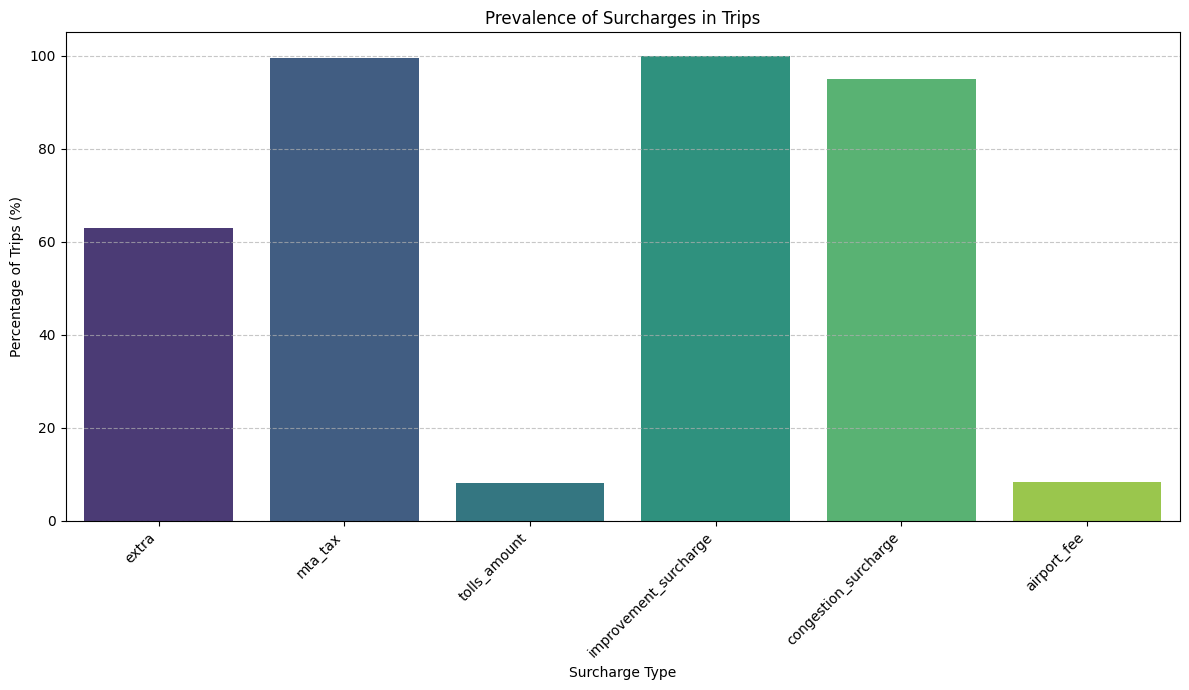

In [169]:
# How often is each surcharge applied?
surcharge_columns = ['extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

surcharge_prevalence = pd.DataFrame(columns=['Surcharge', 'Prevalence (%)'])

for col in surcharge_columns:
    # Calculate the number of trips where the surcharge is applied (value > 0)
    applied_count = (df_nonzero[col] > 0).sum()
    total_trips = len(df_nonzero)

    # Calculate prevalence as a percentage
    prevalence_percent = (applied_count / total_trips) * 100
    surcharge_prevalence = pd.concat([
        surcharge_prevalence,
        pd.DataFrame([{'Surcharge': col, 'Prevalence (%)': prevalence_percent}])
    ], ignore_index=True)

print("Prevalence of each surcharge (percentage of trips where the charge is > 0):")
display(surcharge_prevalence.sort_values(by='Prevalence (%)', ascending=False))

# Visualize the prevalence of surcharges
plt.figure(figsize=(12, 7))
sns.barplot(x='Surcharge', y='Prevalence (%)', data=surcharge_prevalence, palette='viridis')
plt.title('Prevalence of Surcharges in Trips')
plt.xlabel('Surcharge Type')
plt.ylabel('Percentage of Trips (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Based on the exploratory analysis of the 2023 NYC Yellow Taxi dataset, the following strategies are recommended to optimize fleet utilization and operational efficiency:

1. **Optimize Routing via Real-Time Speed Monitoring**

Insight: Analysis of route velocities reveals significant bottlenecks where average speeds drop below 10 mph, particularly on corridors connecting JFK/LGA to Midtown Manhattan.

Strategy: Implement a dynamic routing system that identifies these low-velocity windows (specifically the 16:00–19:00 peak). By incentivizing drivers to utilize alternative arterial roads or focusing on shorter, high-turnover "inner-borough" trips during these hours, the company can minimize idle time in congestion and increase the number of completed trips per shift.

2. **Align Fleet Capacity with Temporal Demand Peaks**

Insight: Trip volume exhibits a clear bimodal distribution on weekdays, with a primary surge during the evening "rush hour" (17:00–19:00). Conversely, demand troughs significantly between 03:00 and 05:00.

Strategy: Shift scheduling should be staggered to ensure maximum "Wheels on Road" (WOR) availability starting at 16:30. Reducing active units during the early morning hours will decrease fuel overhead and driver fatigue, allowing for a more aggressive deployment during high-revenue evening windows.

3. **Geospatial Prioritization of High-Density Zones**

Insight: Heatmaps and volume analysis confirm that demand is heavily concentrated in Manhattan’s central business districts (Midtown, Penn Station) and the Upper East Side. While Airport trips offer higher fare totals, their lower frequency and high deadhead (empty return) risk make them less efficient than high-frequency Manhattan loops.

Strategy: Dispatching logic should prioritize "Zone Clustering" in Manhattan during peak hours to maintain a high vehicle-to-passenger ratio. Airport dispatches should be limited to pre-booked reservations or coordinated with flight arrival schedules to ensure immediate back-to-back fares.

4. **Adaptive Weekday vs. Weekend Deployment Models**

Insight: The data shows a shift in consumer behavior over the weekend; the morning commute peak disappears, replaced by sustained high demand on Friday and Saturday late-nights (22:00–02:00) driven by the leisure and hospitality sectors.

Strategy: Transition from a "Commuter Model" (Monday–Thursday) to a "Leisure Model" (Friday–Sunday). This involves repositioning the fleet toward entertainment hubs and nightlife districts during weekend nights, where higher "Tip Amounts" and "Surge" opportunities typically occur.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

### **Strategic Cab Positioning and Dispatching Recommendations:**

Based on the analysis of temporal and geographical demand patterns, here are recommendations for strategically positioning cabs to optimize supply and meet customer demand:

1.  **Anticipate Peak Hours and Days:**
    *   **Insight:** The busiest hours are **6 PM (18:00)** with **326,260 actual trips**, followed closely by **5 PM (17:00)**. **Thursday** is the busiest day, and **May** is the busiest month.
    *   **Recommendation:** Deploy a higher concentration of cabs to high-demand areas during these peak hours, especially on Thursdays and throughout May. Pre-positioning cabs in commercial districts, entertainment hubs, and transportation centers (like airports) just before the peak hours will minimize wait times and maximize pickups.

2.  **Focus on High-Demand Zones:**
    *   **Insight:** Top pickup zones include "Upper East Side South," "Midtown Center," "JFK Airport," and "LaGuardia Airport." Top dropoff zones also overlap significantly with these, indicating high-traffic areas.
    *   **Recommendation:** Establish virtual "geofenced" zones around these high-demand areas. Use predictive analytics to forecast demand in these zones and strategically re-route idle cabs or dispatch incoming cabs to these areas. Consider setting up designated waiting areas for cabs at major transit points like airports and train stations to ensure a ready supply.

3.  **Optimize for Imbalanced Pickup/Dropoff Ratios:**
    *   **Insight:** Zones with high pickup-to-dropoff ratios (e.g., airports like Rikers Island, JFK Airport, LaGuardia Airport, and East Elmhurst, as shown in the top 10 ratios analysis) indicate areas where cabs frequently drop off passengers but struggle to find immediate return fares. Conversely, zones with low ratios might be destinations from which passengers rarely originate.
    *   **Recommendation:** For zones with high pickup/dropoff ratios, implement incentives for drivers to wait for return fares or facilitate efficient re-positioning to nearby high-demand pickup zones. For zones with extremely low pickup ratios but high dropoffs, consider routing strategies that minimize cab idling time in these areas by quickly re-directing them to more active pickup locations.

4.  **Strategic Night-Time Deployment:**
    *   **Insight:** Night hours (11 PM - 5 AM) show lower overall revenue share (11.98%), but certain zones remain active (e.g., East Village, West Village, JFK Airport) in terms of both pickups and dropoffs.
    *   **Recommendation:** While overall fleet size can be reduced during night hours, maintain a concentrated presence in identified night-time hotspots like entertainment districts (East Village, West Village), major airports (JFK), and key transit hubs. This targeted deployment ensures service availability during essential hours without over-saturating low-demand areas.

5.  **Address Slow Routes and Bottlenecks:**
    *   **Insight:** Identifying routes with the slowest average speeds during specific hours can highlight traffic bottlenecks or inefficient routing (as identified in the `slowest_routes_by_hour` analysis).
    *   **Recommendation:** Utilize real-time traffic data and historical speed patterns to suggest optimal routes to drivers, avoiding known congestion points during peak times. For persistently slow routes, consider re-evaluating the pricing or offering alternative modes of transport if the service becomes unviable.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

### **Data-Driven Adjustments to Pricing Strategy:**

Based on the analysis, here are recommendations for a dynamic pricing strategy to maximize revenue and maintain competitiveness:

1.  **Dynamic Surge Pricing for Peak Hours and High-Demand Zones:**
    *   **Insight:** Peak hours (e.g., 5 PM - 7 PM, Thursday evening) and high-demand zones (e.g., Manhattan's Midtown, Upper East Side South) consistently show the highest trip volumes. Weekends, especially Friday and Saturday nights, also have distinct demand patterns.
    *   **Recommendation:** Implement dynamic surge pricing during these identified peak times and in high-demand geographical areas. This allows for increased revenue capture when demand outstrips supply, common in busy periods. Utilize real-time demand prediction models to identify emerging hot spots and adjust pricing accordingly.

2.  **Tiered Pricing Based on Trip Distance and Duration:**
    *   **Insight:** `fare_amount` has a strong correlation (0.95) with `trip_distance` and a moderate correlation (0.32) with `trip_duration`. Our analysis of 'fare per mile' across distance tiers revealed varying average rates (e.g., higher fare per mile for shorter trips).
    *   **Recommendation:** Maintain and refine a tiered pricing structure that considers both distance and expected duration. For very short trips (0-2 miles), a higher 'fare per mile' might be justifiable due to fixed costs. For longer trips (>5 miles), competitive 'fare per mile' pricing is crucial. Introduce a flexible component that accounts for unexpected delays (e.g., 'extra' charges or adjusted duration-based pricing) during periods of high congestion (as identified by slow routes).

3.  **Optimize Passenger Count-Based Pricing:**
    *   **Insight:** The correlation between `fare_amount` and `passenger_count` is low (0.04), and our analysis of 'average fare per mile per passenger' shows slight variations, with single-passenger trips often subsidizing multi-passenger trips implicitly.
    *   **Recommendation:** Consider a subtle per-passenger surcharge beyond a certain number (e.g., 2 passengers) or a marginal increase in the base fare for multi-passenger trips. This would more accurately reflect the potential increase in wear-and-tear or slightly longer loading/unloading times, without deterring larger groups. Publicize this clearly to avoid customer dissatisfaction.

4.  **Strategic Adjustments for Off-Peak and Night Hours:**
    *   **Insight:** Night hours (11 PM - 5 AM) contribute a significantly lower revenue share (11.98%). While certain zones remain active, overall demand is lower.
    *   **Recommendation:** During low-demand periods and night hours, consider offering minor discounts or fixed, attractive rates to stimulate demand. This can help improve fleet utilization during otherwise quiet periods and attract price-sensitive customers. Incentivize drivers to operate during these times to ensure availability without over-saturating the market.

5.  **Competitive Vendor Analysis:**
    *   **Insight:** The 'average fare per mile by VendorID' analysis can reveal if one vendor consistently charges more or less for similar trips across different times or distance tiers.
    *   **Recommendation:** Regularly monitor and compare pricing with competitors (VendorID 1 vs. VendorID 2, etc.) across various trip segments. Adjust pricing to be competitive where necessary, perhaps offering slight advantages in specific segments where operational efficiency allows for lower costs, or justifying premium pricing with superior service quality.

6.  **Transparent Surcharge Communication:**
    *   **Insight:** Surcharges like congestion surcharge and airport fees are frequently applied. Transparency around these charges is crucial for customer satisfaction.
    *   **Recommendation:** Ensure all surcharges are clearly communicated to passengers upfront (e.g., in the app or quoted fare). While not a pricing strategy in itself, clear communication prevents negative customer experience that could lead to reduced repeat business, which indirectly impacts revenue.

By implementing these data-driven pricing adjustments, the taxi operation can better match pricing to demand, optimize revenue streams, and remain competitive in the dynamic NYC market.